# RAG Evaluation Metrics — Exploration

Loads Langfuse parquet exports from `local/metric-export/` and provides structured analysis across four sections:

1. **Single run** — deep-dive on one session
2. **Multiple runs** — compare configurations via `run_id`
3. **Stability** — compare repeated sessions of the same `run_id`
4. **Statistics** — per-session descriptive stats for a given `run_id`

**Run the export first, for example:**
```bash
python analysis/langfuse_export.py --session-id <your_session_id>
```

## Setup & Data Loading

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Make utils importable from notebook dir
sys.path.insert(0, str(Path.cwd()))

from utils import (
    load_files,
    get_session_ids,
    get_run_ids,
    print_dataset_info,
    plot_boxplot,
    plot_boxplots,
    plot_metrics_grid,
    plot_latency_as_hist,
    plot_generation_as_hist,
    plot_retrieval_as_hist,
    plot_hardware_as_hist,
    plot_generation_quality_as_hist,
    plot_scatter_two_metrics,
    plot_heatmap,
    stats_by_group,
    plot_stats_bar,
    plot_stats_line,
    plot_stats_multi_line,
    find_outliers,
    exclude_outliers,
    plot_dot_profiles,
    _present,
    _numeric_metric_cols,
    LATENCY_COLS,
    GENERATION_COLS,
    RETRIEVAL_COLS,
    HARDWARE_COLS,
    GENERATION_QUALITY_COLS,
    METRIC_LABELS,
)

EXPORT_DIR = Path("../local/metric-export/eval2")

### Load dataset(s)

Adjust `folder` / `pattern` or pass explicit `paths` to `load_files()`.  
The cell prints all session IDs, run IDs, and column names.

In [2]:
# Load all exports matching a pattern, or pass explicit paths=["file1.parquet", ...]
df = load_files(folder=EXPORT_DIR, pattern="*langfuse_export*.parquet")

print_dataset_info(df)

Loading: 2026-03-11_11-44_langfuse_export_e5_large_test_ministral_3_3B_q5_61_67d3dd6d.parquet
Loading: 2026-03-11_11-44_langfuse_export_e5_large_test_ministral_3_3B_q8_61_7ee0add1.parquet
Loading: 2026-03-11_11-44_langfuse_export_e5_large_test_ministral_3_8B_q4_61_cdf192c3.parquet
Loading: 2026-03-11_11-44_langfuse_export_e5_large_test_ministral_3_8B_q5_61_5409d5d5.parquet
Loading: 2026-03-11_11-44_langfuse_export_e5_large_test_mistral_7B_0_3_iq3_61_e2c616ff.parquet
Loading: 2026-03-11_11-44_langfuse_export_e5_large_test_mistral_7B_0_3_q3l_61_1615373d.parquet
Loading: 2026-03-11_11-44_langfuse_export_e5_large_test_mistral_7B_0_3_q4_61_e70af912.parquet
Loading: 2026-03-11_11-44_langfuse_export_e5_large_test_mistral_7B_0_3_q8_61_7749bcc4.parquet
Loading: 2026-03-11_11-45_langfuse_export_e5_large_test_ministral_3_3B_q4_61_1550665d.parquet
Loading: 2026-03-11_11-45_langfuse_export_e5_large_test_ministral_3_3B_q4_61_9b1925cc.parquet
Loading: 2026-03-11_11-45_langfuse_export_e5_large_test_mi

## Quick NaN & Outlier Analysis

In [3]:
# metric_cols: numeric, non-boolean metric columns (safe for quantile ops)
metric_cols = _numeric_metric_cols(df)

# --- NaN counts ---
nan_counts = df[metric_cols].isna().sum()
nan_pct = (nan_counts / len(df) * 100).round(1)
nan_df = pd.DataFrame({"nan_count": nan_counts, "nan_pct": nan_pct})
nan_df = nan_df[nan_df["nan_count"] > 0].sort_values("nan_pct", ascending=False)

if nan_df.empty:
    print("No NaNs in metric columns.")
else:
    print("Columns with NaN values:")
    display(nan_df)

Columns with NaN values:


,nan_count,nan_pct
score_Evaluate Hallucination V2,22,0.6
score_Faithfulness custom,19,0.5
score_Correctness,8,0.2


In [4]:
# --- Outlier detection (IQR method, flag extreme values) ---
outlier_summary = {}
for col in metric_cols:
    series = df[col].dropna()
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        continue
    n_outliers = ((series < (q1 - 3 * iqr)) | (series > (q3 + 3 * iqr))).sum()
    if n_outliers > 0:
        outlier_summary[col] = {"outliers (3×IQR)": n_outliers, "pct": round(n_outliers / len(series) * 100, 1)}

if outlier_summary:
    print("Columns with extreme outliers (|z| > 3×IQR):")
    display(pd.DataFrame(outlier_summary).T.sort_values("pct", ascending=False))
else:
    print("No extreme outliers detected.")

Columns with extreme outliers (|z| > 3×IQR):


,outliers (3×IQR),pct
hardware_swap_in_bytes,256.0,6.8
hardware_swap_out_bytes,122.0,3.2
hardware_avg_cpu_utilization_pct,61.0,1.6
latency_retrieval_latency_ms,19.0,0.5
latency_ms,16.0,0.4
latency_e2e_latency_ms,13.0,0.3
latency_llm_generation_latency_ms,3.0,0.1
latency_predicted_ms,3.0,0.1
latency_predicted_per_token_ms,2.0,0.1
latency_ttft_ms,1.0,0.0


### Outlier Inspection

`find_outliers` returns a table of all rows flagged as outliers, annotated with the triggering column, its value, and the computed bounds. Use `exclude_outliers` to produce a cleaned copy of the DataFrame.

In [5]:
# Inspect outliers across all numeric metric columns.
# Tune `method` ("iqr" or "zscore") and `threshold` to adjust sensitivity.
outliers = find_outliers(df, method="iqr", threshold=3.0)

if outliers.empty:
    print("No outliers detected.")
else:
    print(f"{len(outliers)} outlier row(s) found across {outliers['outlier_col'].nunique()} column(s).\n")
    print(f"Columns: {outliers['outlier_col'].unique()}")
    display(outliers)

497 outlier row(s) found across 11 column(s).

Columns: <ArrowStringArray>
[ 'hardware_avg_cpu_utilization_pct',            'hardware_swap_in_bytes',
           'hardware_swap_out_bytes',            'latency_e2e_latency_ms',
 'latency_llm_generation_latency_ms',                        'latency_ms',
              'latency_predicted_ms',    'latency_predicted_per_token_ms',
                 'latency_prompt_ms',      'latency_retrieval_latency_ms',
                   'latency_ttft_ms']
Length: 11, dtype: str


,outlier_col,value,lower,upper,session_id,run_id,claim_id,trace_id,latency_ms,latency_ttft_ms,...,metrics_precision_at_k,metrics_mrr,latency_e2e_latency_ms,hardware_max_ram_usage_mb,hardware_avg_cpu_utilization_pct,hardware_swap_in_bytes,hardware_swap_out_bytes,score_Faithfulness custom,score_Evaluate Hallucination V2,score_Correctness
69,hardware_avg_cpu_utilization_pct,77.250000,-7.4000,36.3500,e5_large_test_mistral_7B_0_3_q8_61_7749bcc4,e5_large_test_mistral_7B_0_3_q8_61,emanual_543,be33e1aeb752b537548785b9d2c7db0f,7059.0,2674.794173,...,0.200000,1.000000,7037.532375,11419.078125,77.25,190464000,606208,0.670,0.00,0.4
70,hardware_avg_cpu_utilization_pct,74.550000,-7.4000,36.3500,e5_large_test_mistral_7B_0_3_q8_61_7749bcc4,e5_large_test_mistral_7B_0_3_q8_61,emanual_637,2b9817a486d1283ea8686b8e3d04418a,8336.0,2716.139954,...,0.250000,1.000000,8303.192167,11062.890625,74.55,143130624,1146880,0.833,0.10,0.4
117,hardware_avg_cpu_utilization_pct,74.550000,-7.4000,36.3500,e5_large_llama_3_2_3B_q5_61_2017b719,e5_large_llama_3_2_3B_q5_61,emanual_430,63b8fef7f0790179a194d1f4d8d1c0e1,7628.0,884.579762,...,0.400000,0.333333,7594.401958,7944.156250,74.55,3162112,475136,0.923,0.15,0.7
107,hardware_avg_cpu_utilization_pct,74.250000,-7.4000,36.3500,e5_large_llama_3_2_3B_q8_61_4b9b1e6f,e5_large_llama_3_2_3B_q8_61,emanual_548,7925f93e7b9cd4b723d50791e690a94c,3310.0,1093.223064,...,0.600000,1.000000,3294.467834,10498.859375,74.25,83542016,1409024,1.000,0.00,1.0
66,hardware_avg_cpu_utilization_pct,71.500000,-7.4000,36.3500,e5_large_test_mistral_7B_0_3_q4_61_e70af912,e5_large_test_mistral_7B_0_3_q4_61,emanual_282,ce47e5f321b468933cd2d844d51c8307,3538.0,2508.302640,...,0.250000,1.000000,3515.740500,8717.953125,71.50,39337984,524288,1.000,0.00,0.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26,latency_retrieval_latency_ms,314.487917,-100.4381,289.1656,e5_large_test_ministral_3_3B_q8_61_7ee0add1,e5_large_test_ministral_3_3B_q8_61,emanual_237,6f7c53b54902fe45942ae725d471875d,4744.0,764.485062,...,0.500000,1.000000,4713.478667,8397.593750,23.80,20299776,294912,0.800,0.25,1.0
44,latency_retrieval_latency_ms,296.573542,-100.4381,289.1656,e5_large_llama_3_2_3B_q5_61_2017b719,e5_large_llama_3_2_3B_q5_61,emanual_116,428a311792e106664fc134e29cef17e3,7275.0,1296.801284,...,0.500000,1.000000,7256.195291,7787.921875,25.00,22085632,2015232,0.580,0.60,0.2
38,latency_retrieval_latency_ms,290.264708,-100.4381,289.1656,e5_large_llama_3_2_3B_q8_61_b3c86b91,e5_large_llama_3_2_3B_q8_61,emanual_413,03964d421177e19e1b215df460cc451e,7430.0,821.430938,...,0.166667,1.000000,7407.368833,9996.453125,23.90,310657024,344064,0.500,0.15,0.9
32,latency_retrieval_latency_ms,289.170958,-100.4381,289.1656,e5_large_test_mistral_7B_0_3_q4_61_28663353,e5_large_test_mistral_7B_0_3_q4_61,emanual_558,a7aa94fbbcbc00c276c94de3c4237f02,5675.0,3224.569263,...,0.500000,1.000000,5665.876792,8880.546875,11.50,3260416,65536,1.000,0.00,0.6


In [6]:
# Analyze specific columns

# cols_to_display = ['hardware_avg_cpu_utilization_pct']
# outliers[outliers['outlier_col'].isin(cols_to_display)]
# display(outliers[outliers['outlier_col'].isin(cols_to_display)])

In [7]:
# Narrow the inspection to specific columns if needed, e.g. latency only:
#   find_outliers(df, cols=LATENCY_COLS, method="iqr", threshold=3.0)

# Exclude outliers and continue analysis with the cleaned frame.
# Adjust cols to limit exclusion to a specific metric group:
#   df_clean = exclude_outliers(df, cols=LATENCY_COLS)

# df = exclude_outliers(df, method="iqr", threshold=3.0)
# print(f"Clean shape: {df.shape}")

---
# 1  Single Run Analysis

One parquet file = one session. Select a `SESSION_ID` below to drill into all traces for that session.

In [8]:
# Set the session to inspect (copy from the printed list above)
SESSION_ID = get_session_ids(df)[0]  # default: first session; replace with a string literal

df_single = df[df["session_id"] == SESSION_ID].copy()
print(f"Session: {SESSION_ID}")
print(f"Traces:  {len(df_single)}")

Session: e5_large_llama_3_2_3B_q1_61_0ec85db0
Traces:  61


In [9]:
single_metric_cols = _numeric_metric_cols(df_single)
df_single[single_metric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
latency_ms,61.0,6.842410e+03,4.659651e+02,6220.000000,6.647000e+03,6.816000e+03,6.919000e+03,1.007800e+04
latency_ttft_ms,61.0,9.830555e+02,1.789907e+02,503.163934,8.623941e+02,9.831554e+02,1.103458e+03,1.342635e+03
latency_llm_generation_latency_ms,61.0,5.711025e+03,2.564353e+01,5669.615000,5.698384e+03,5.706779e+03,5.719338e+03,5.825409e+03
latency_prompt_ms,61.0,9.607469e+02,1.789419e+02,481.017000,8.401020e+02,9.608410e+02,1.081019e+03,1.320223e+03
latency_predicted_ms,61.0,5.711025e+03,2.564353e+01,5669.615000,5.698384e+03,5.706779e+03,5.719338e+03,5.825409e+03
latency_predicted_per_token_ms,61.0,2.230869e+01,1.001700e-01,22.146934,2.225931e+01,2.229211e+01,2.234116e+01,2.275550e+01
generation_prompt_tokens,61.0,5.067869e+02,8.923622e+01,348.000000,4.370000e+02,5.100000e+02,5.690000e+02,6.880000e+02
generation_completion_tokens,61.0,2.560000e+02,0.000000e+00,256.000000,2.560000e+02,2.560000e+02,2.560000e+02,2.560000e+02
generation_tokens_per_second,61.0,4.482646e+01,1.995161e-01,43.945412,4.476043e+01,4.485893e+01,4.492502e+01,4.515298e+01
latency_retrieval_latency_ms,61.0,9.560175e+01,4.709010e+01,29.271667,5.786008e+01,9.044783e+01,1.333236e+02,2.258882e+02


## 1.2  Metric Plots

In [10]:
# plot_latency_as_hist(df_single)
# plot_generation_as_hist(df_single)
# plot_retrieval_as_hist(df_single)
# plot_hardware_as_hist(df_single)
# plot_generation_quality_as_hist(df_single)

---
# 2  Multiple Runs Analysis

Compare across different configurations (different `run_id` values). Load all files or a filtered subset below.

In [11]:
run_order = [
  "e5_large_llama_3_2_3B_q1_61",
  "e5_large_llama_3_2_3B_q2_61",
  "e5_large_llama_3_2_3B_q3_61",
  "e5_large_llama_3_2_3B_q4_61",
  "e5_large_llama_3_2_3B_q5_61",
  "e5_large_llama_3_2_3B_q8_61",
  "e5_large_test_ministral_3_3B_q4_61",
    "e5_large_test_ministral_3_3B_q5_61",
  "e5_large_test_ministral_3_3B_q8_61",
  "e5_large_test_ministral_3_8B_q4_61",
  "e5_large_test_ministral_3_8B_q5_61",
  "e5_large_test_mistral_7B_0_3_iq3_61",
  "e5_large_test_mistral_7B_0_3_q3l_61",
  "e5_large_test_mistral_7B_0_3_q4_61",
  "e5_large_test_mistral_7B_0_3_q8_61",
  "e5_large_mistral_large_latest_61",
]

# run_order = None
labels = {
  "e5_large_test_ministral_3_3B_q4_61": "Ministral3 3B Q4", 
  "e5_large_test_ministral_3_3B_q5_61": "Ministral3 3B Q5",
  "e5_large_test_ministral_3_3B_q8_61": "Ministral3 3B Q8",
  "e5_large_test_ministral_3_8B_q4_61": "Ministral3 8B Q4",
  "e5_large_test_ministral_3_8B_q5_61": "Ministral3 8B Q5",
  "e5_large_test_mistral_7B_0_3_iq3_61": "Mistral 7Bv0.3 IQ3",
  "e5_large_test_mistral_7B_0_3_q3l_61": "Mistral 7Bv0.3 Q3L",
  "e5_large_test_mistral_7B_0_3_q4_61": "Mistral 7Bv0.3 Q4",
  "e5_large_test_mistral_7B_0_3_q8_61": "Mistral 7Bv0.3 Q8",
  "e5_large_mistral_large_latest_61": "Mistral Large",
  "e5_large_llama_3_2_3B_q1_61": "Llama_3.2 3B Q1",
  "e5_large_llama_3_2_3B_q2_61": "Llama_3.2 3B Q2",
  "e5_large_llama_3_2_3B_q3_61": "Llama_3.2 3B Q3",
  "e5_large_llama_3_2_3B_q4_61": "Llama_3.2 3B Q4",
  "e5_large_llama_3_2_3B_q5_61": "Llama_3.2 3B Q5",
  "e5_large_llama_3_2_3B_q8_61": "Llama_3.2 3B Q8",
}

## 2.1  Mean Metrics per Run ID

In [12]:
multi_metric_cols = _numeric_metric_cols(df)
df.groupby("run_id")[multi_metric_cols].median().round(3)


# selection = ["e5_large_llama_3_2_3B_q4_61", "e5_large_llama_3_2_3B_q5_61", "e5_large_test_ministral_3_3B_q4_61", "e5_large_test_ministral_3_3B_q5_61"]
# df_select = df[df["run_id"].isin(selection)]
# multi_metric_cols = _numeric_metric_cols(df_select)
# df_select.groupby("run_id")[multi_metric_cols].median().round(3)

,latency_ms,latency_ttft_ms,latency_llm_generation_latency_ms,latency_prompt_ms,latency_predicted_ms,latency_predicted_per_token_ms,generation_prompt_tokens,generation_completion_tokens,generation_tokens_per_second,latency_retrieval_latency_ms,...,metrics_precision_at_k,metrics_mrr,latency_e2e_latency_ms,hardware_max_ram_usage_mb,hardware_avg_cpu_utilization_pct,hardware_swap_in_bytes,hardware_swap_out_bytes,score_Faithfulness custom,score_Evaluate Hallucination V2,score_Correctness
run_id,,,,,,,,,,,,,,,,,,,,,
e5_large_llama_3_2_3B_q1_61,6807.0,1018.768,5704.287,995.665,5704.287,22.291,511.0,256.0,44.862,100.182,...,0.5,1.0,6799.714,6562.500,15.350,19087360.0,622592.0,0.000,1.00,0.05
e5_large_llama_3_2_3B_q2_61,5918.0,1056.761,4786.318,1035.698,4786.318,20.871,517.0,256.0,47.913,104.706,...,0.5,1.0,5907.092,8673.188,16.050,34488320.0,393216.0,0.867,0.10,0.70
e5_large_llama_3_2_3B_q3_61,4045.0,1028.889,2975.816,1007.153,2975.816,21.516,515.0,137.0,46.478,95.403,...,0.5,1.0,4026.458,8123.547,18.350,19529728.0,344064.0,0.900,0.10,0.70
e5_large_llama_3_2_3B_q4_61,4270.0,1028.157,3122.213,1009.248,3122.213,19.476,515.0,150.0,51.346,92.425,...,0.5,1.0,4263.894,7598.703,18.800,15499264.0,425984.0,0.917,0.05,0.70
e5_large_llama_3_2_3B_q5_61,5413.0,1097.481,4163.584,1074.355,4163.584,23.517,515.0,180.0,42.523,99.344,...,0.5,1.0,5392.014,8099.969,16.850,11239424.0,344064.0,0.857,0.10,0.70
e5_large_llama_3_2_3B_q8_61,5507.0,931.826,4443.774,906.640,4443.774,24.302,515.0,190.0,41.149,104.264,...,0.5,1.0,5489.929,8623.453,19.550,23674880.0,442368.0,0.920,0.10,0.65
e5_large_mistral_large_latest_61,4203.0,441.387,3611.284,441.387,3611.284,0.000,530.0,241.0,63.452,79.540,...,0.5,1.0,4195.402,5507.375,13.950,3702784.0,327680.0,1.000,0.00,0.95
e5_large_test_ministral_3_3B_q4_61,6197.0,1121.224,5278.520,1100.532,5278.520,20.782,521.0,256.0,48.119,66.624,...,0.5,1.0,6193.733,7323.727,11.625,5898240.0,335872.0,0.875,0.10,0.90
e5_large_test_ministral_3_3B_q5_61,7569.5,1253.616,6511.912,1228.070,6511.912,25.725,521.0,253.5,38.873,77.278,...,0.5,1.0,7564.171,7706.195,12.750,13639680.0,516096.0,0.890,0.10,0.85


## 2.2  Boxplots by Run ID

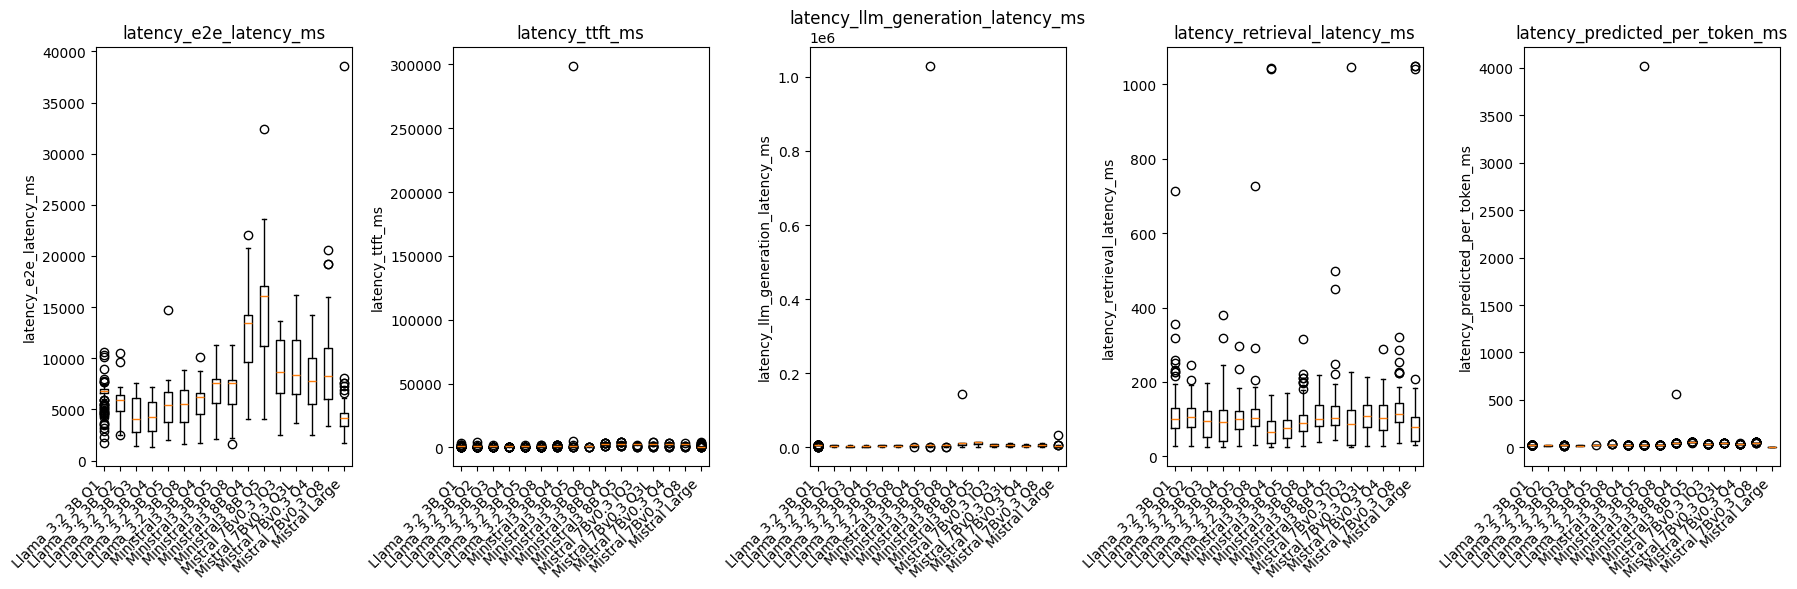

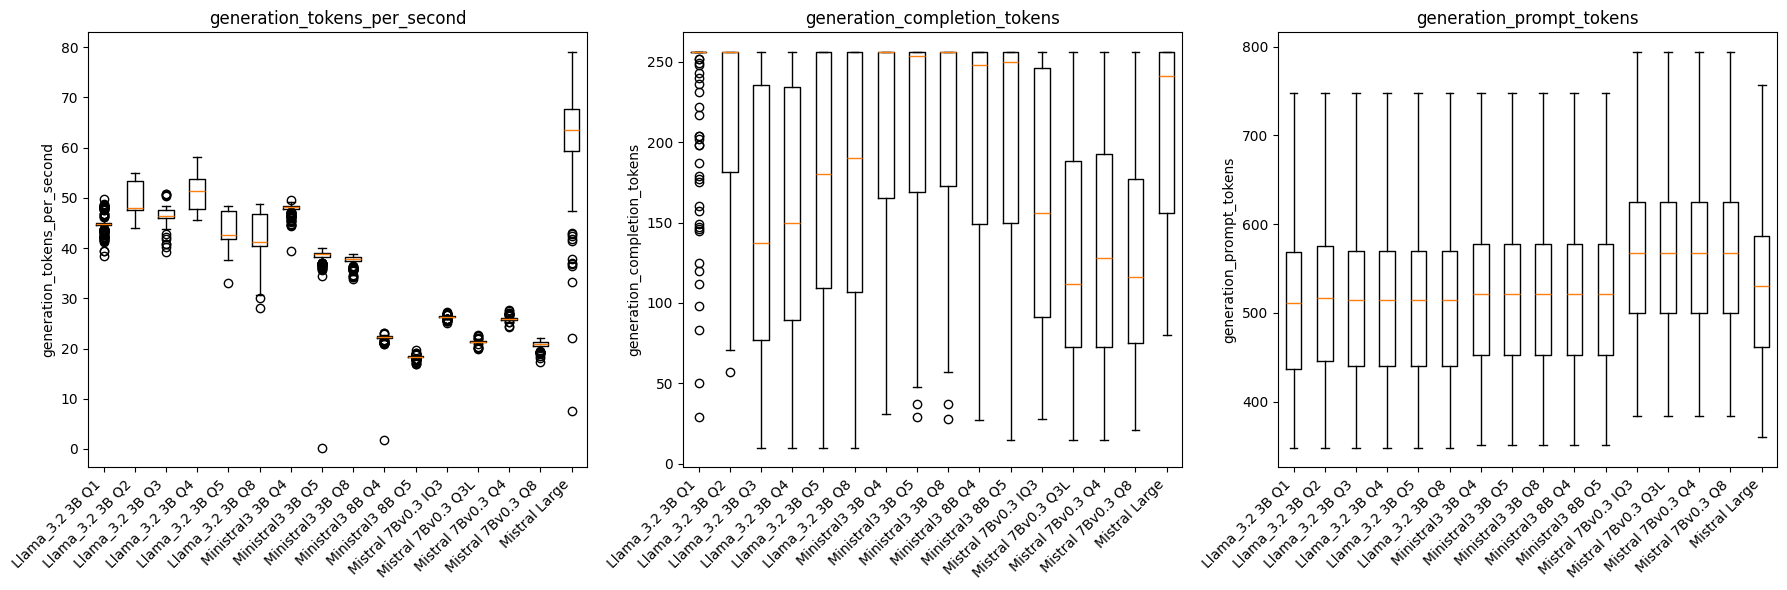

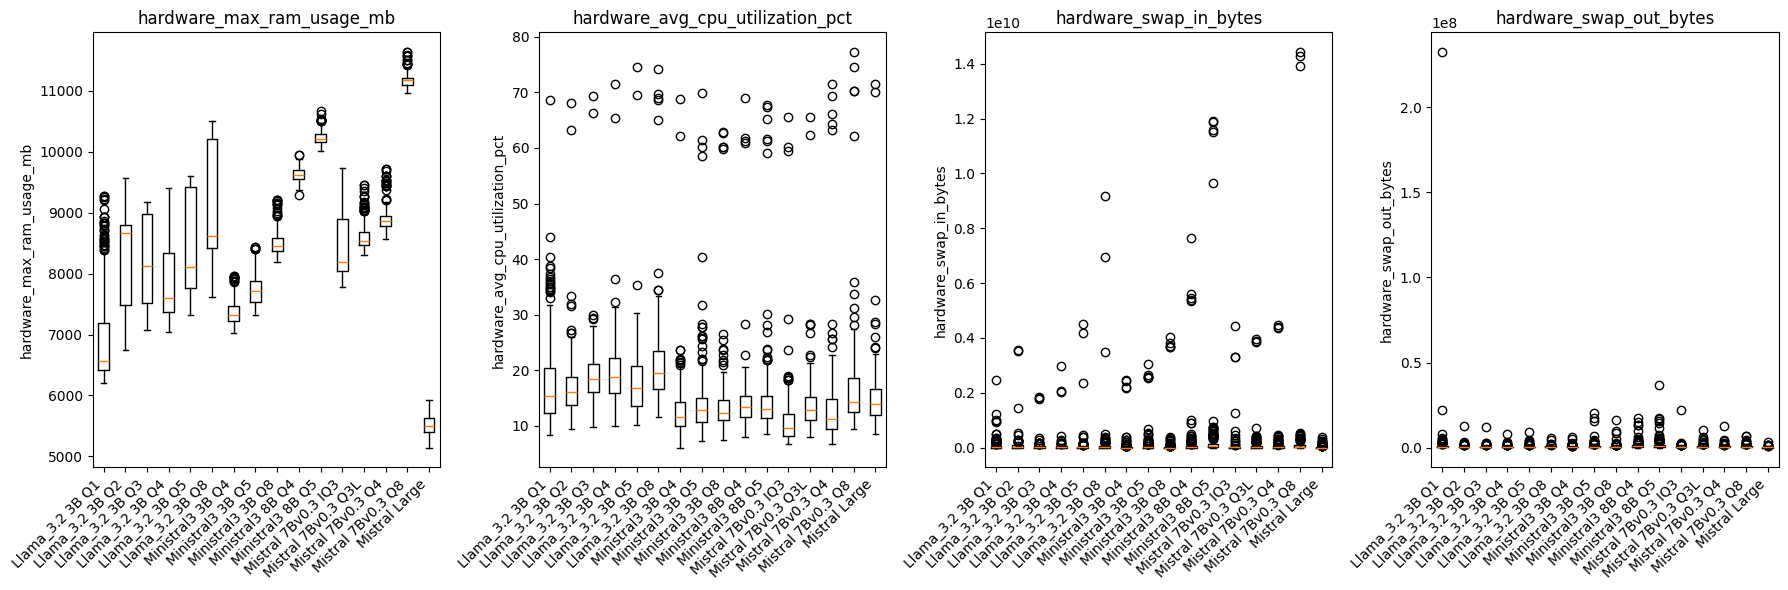

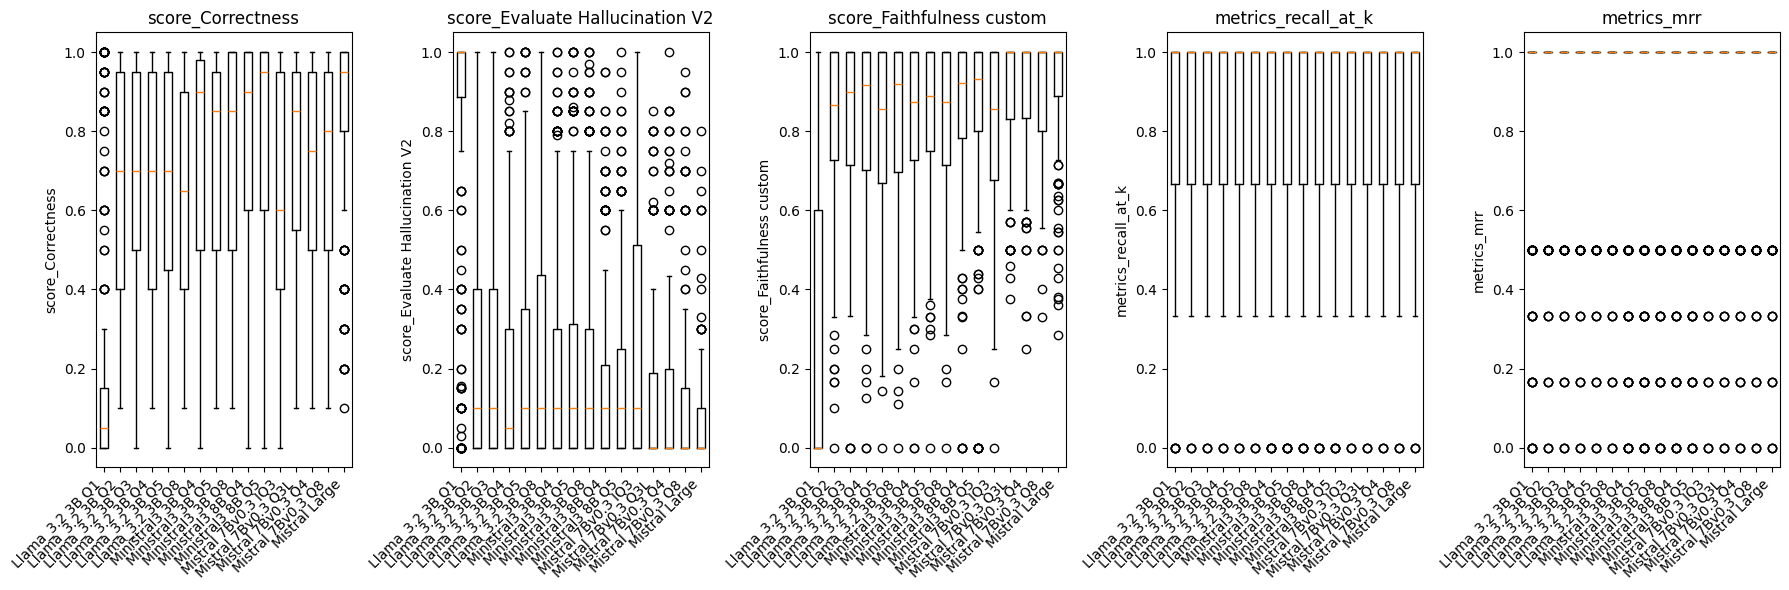

(<Figure size 1800x600 with 5 Axes>,
 [<Axes: title={'center': 'score_Correctness'}, ylabel='score_Correctness'>,
  <Axes: title={'center': 'score_Evaluate Hallucination V2'}, ylabel='score_Evaluate Hallucination V2'>,
  <Axes: title={'center': 'score_Faithfulness custom'}, ylabel='score_Faithfulness custom'>,
  <Axes: title={'center': 'metrics_recall_at_k'}, ylabel='metrics_recall_at_k'>,
  <Axes: title={'center': 'metrics_mrr'}, ylabel='metrics_mrr'>])

In [13]:
# Optional: set explicit order for run_ids on the x axis

plot_boxplots(df, LATENCY_COLS,
              group_by="run_id", group_order=run_order, figsize=(18, 6), labels=labels)

plot_boxplots(df, GENERATION_COLS,
              group_by="run_id", group_order=run_order, figsize=(18, 6), labels=labels)

plot_boxplots(df, HARDWARE_COLS,
              group_by="run_id", group_order=run_order, figsize=(18, 6), labels=labels)

plot_boxplots(df, GENERATION_QUALITY_COLS,
              group_by="run_id", group_order=run_order, figsize=(18, 6), labels=labels)


## 2.3  Lines Across Run IDs

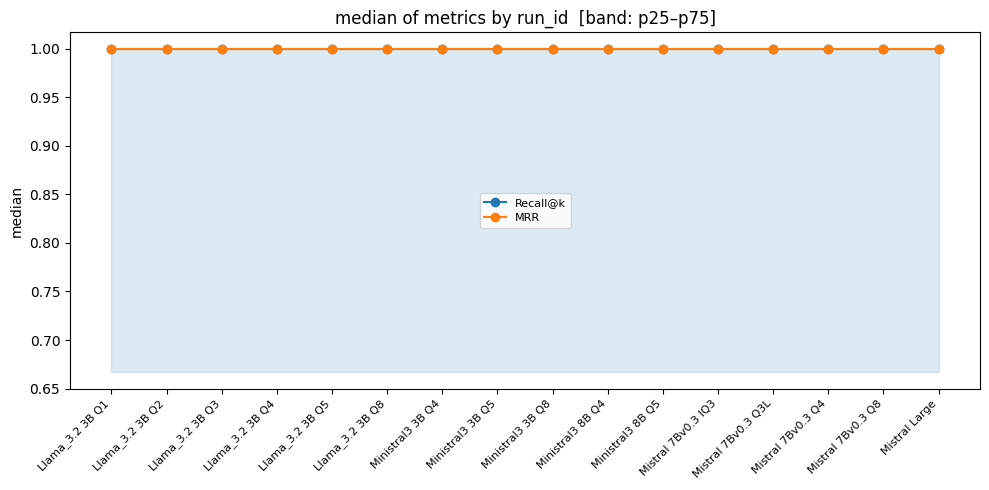

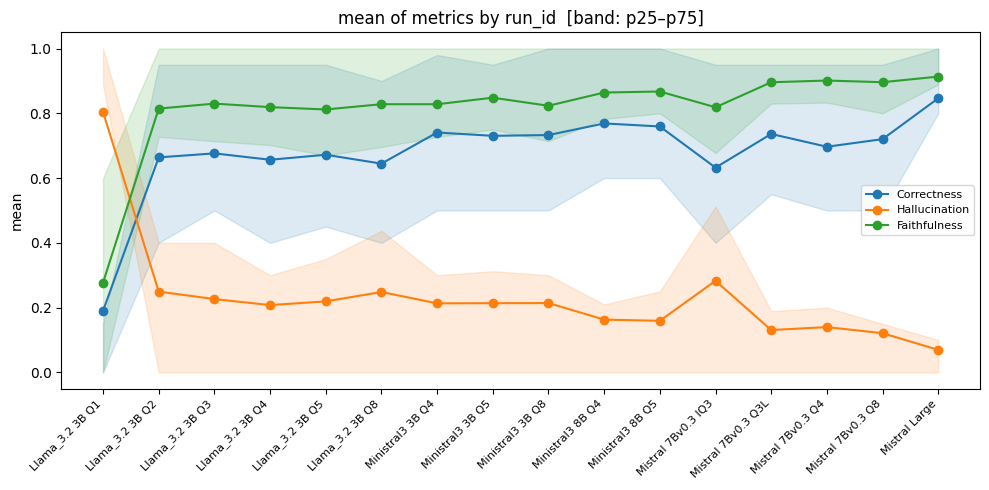

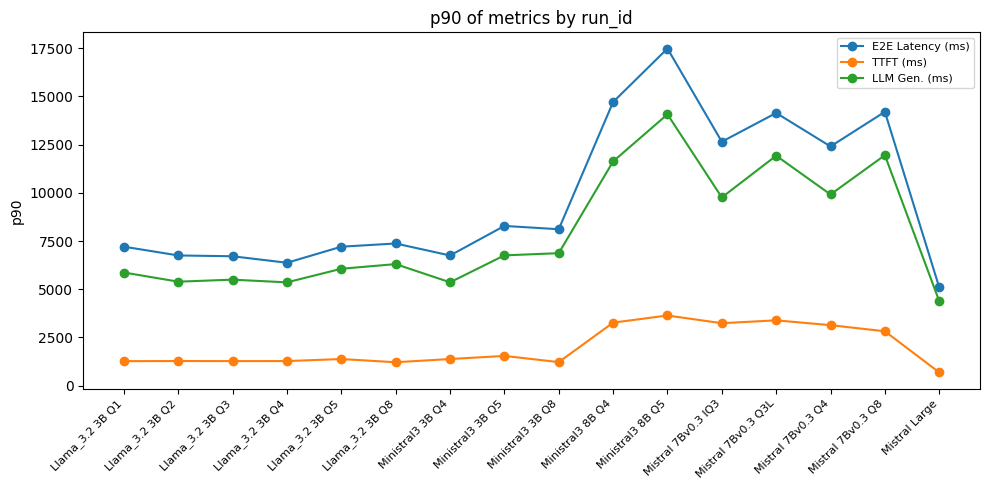

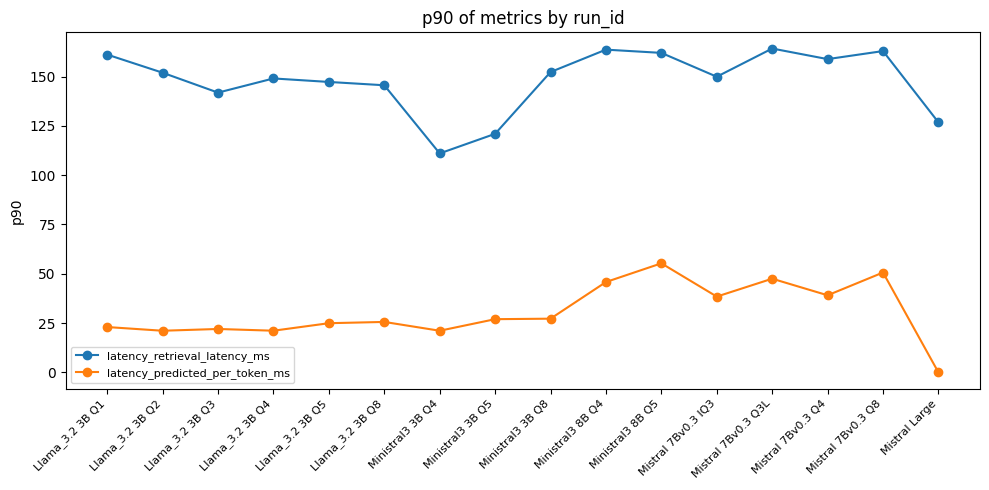

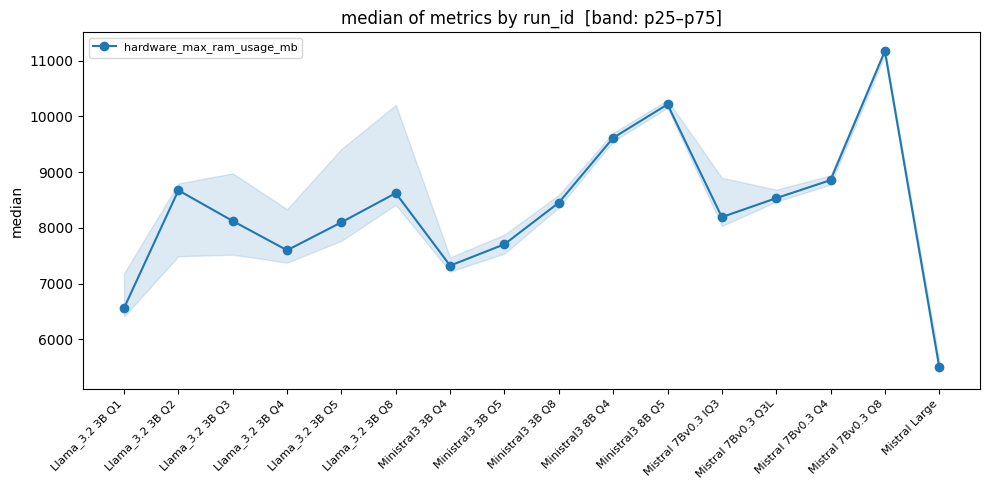

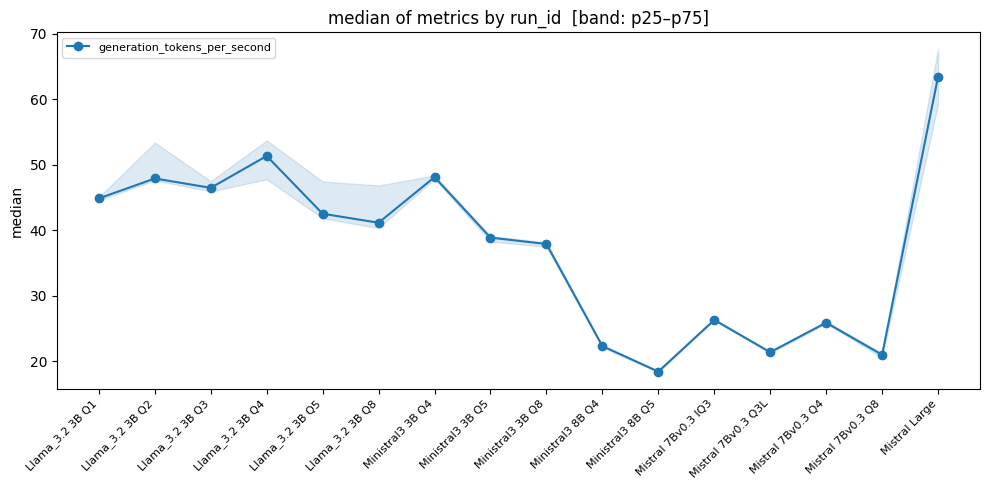

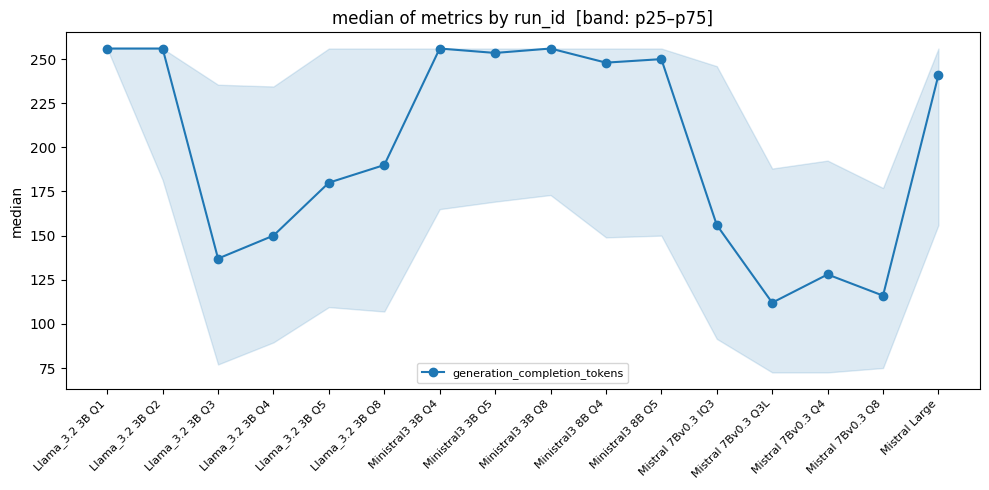

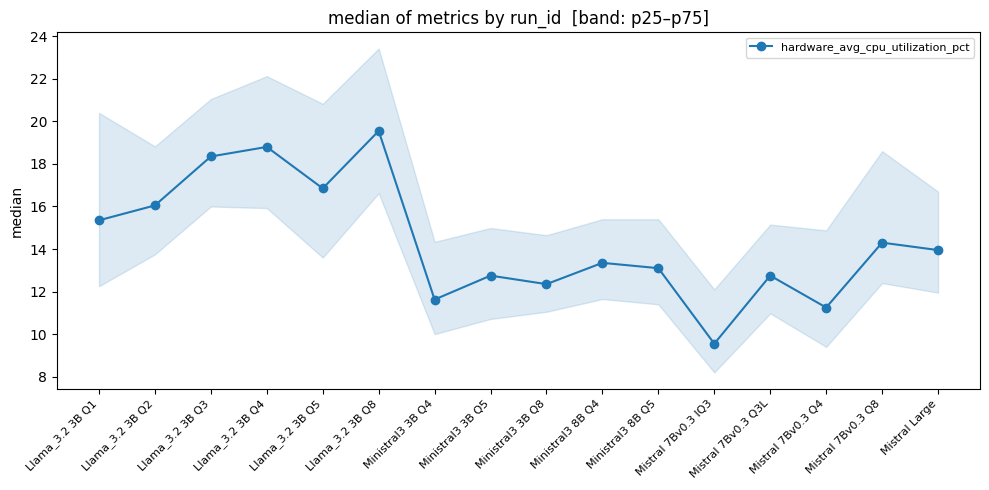

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'median of metrics by run_id  [band: p25–p75]'}, ylabel='median'>)

In [15]:
plot_stats_multi_line(df, _present(df, ["metrics_recall_at_k",
                                  "metrics_mrr"]),
                      group_by="run_id", group_order=run_order, stat="median", show_band=True, labels=labels, metric_labels=METRIC_LABELS)

plot_stats_multi_line(df, _present(df, ["score_Correctness",
                                  "score_Evaluate Hallucination V2", "score_Faithfulness custom"]),
                      group_by="run_id", group_order=run_order, stat="mean", show_band=True, labels=labels, metric_labels=METRIC_LABELS)

plot_stats_multi_line(df, _present(df, ["latency_e2e_latency_ms", "latency_ttft_ms", "latency_llm_generation_latency_ms"]),
                      group_by="run_id", group_order=run_order, stat="p90", labels=labels, metric_labels=METRIC_LABELS)

plot_stats_multi_line(df,
                      _present(df, ["latency_retrieval_latency_ms", "latency_predicted_per_token_ms"]),
                      group_by="run_id", group_order=run_order, stat="p90", labels=labels)

plot_stats_multi_line(df,
                      _present(df, ["hardware_max_ram_usage_mb"]),
                      group_by="run_id", group_order=run_order, stat="median", show_band=True, labels=labels)

plot_stats_multi_line(df,
                      _present(df, ["generation_tokens_per_second"]),
                      group_by="run_id", group_order=run_order, stat="median", show_band=True, labels=labels)

plot_stats_multi_line(df,
                      _present(df, ["generation_completion_tokens"]),
                      group_by="run_id", group_order=run_order, stat="median", show_band=True, labels=labels)


plot_stats_multi_line(df,
                      _present(df, ["hardware_avg_cpu_utilization_pct"]),
                      group_by="run_id", group_order=run_order, stat="median", show_band=True, labels=labels)

## Extra: How do the models deal with low recall, i.e., unrelated context

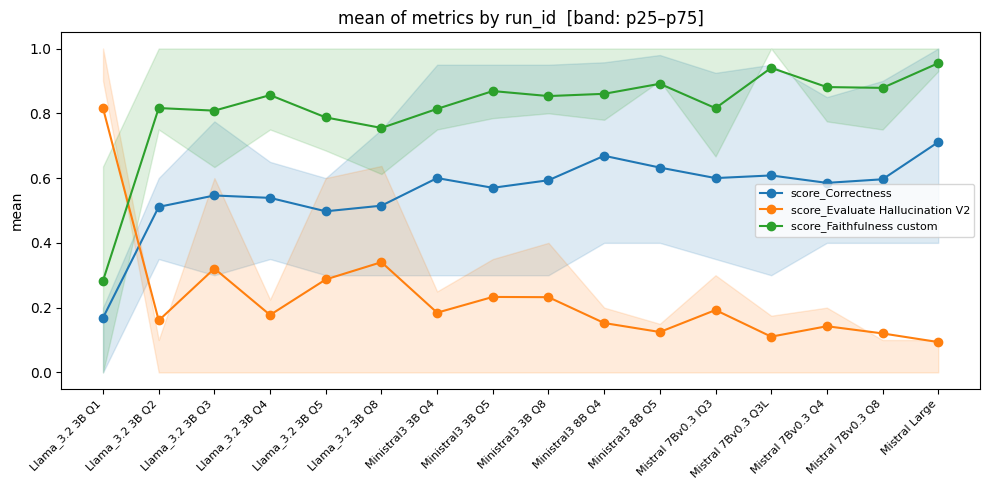

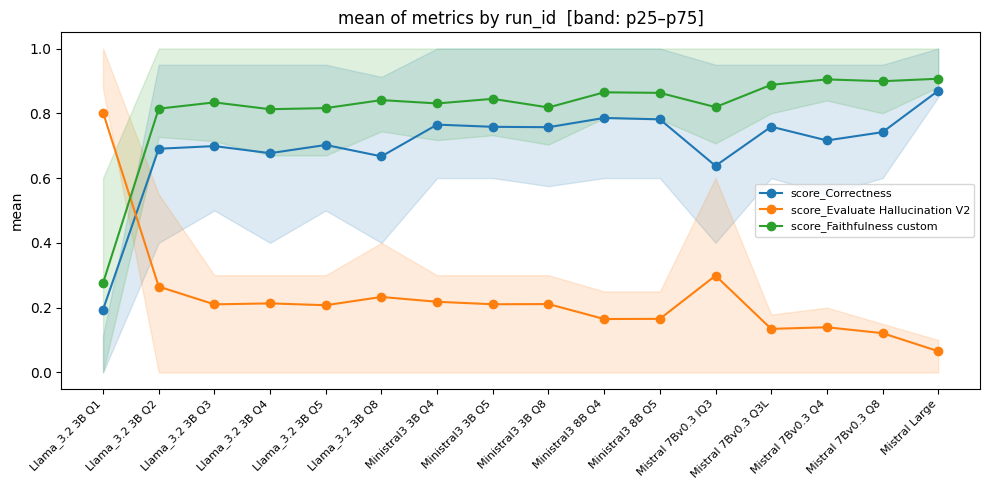

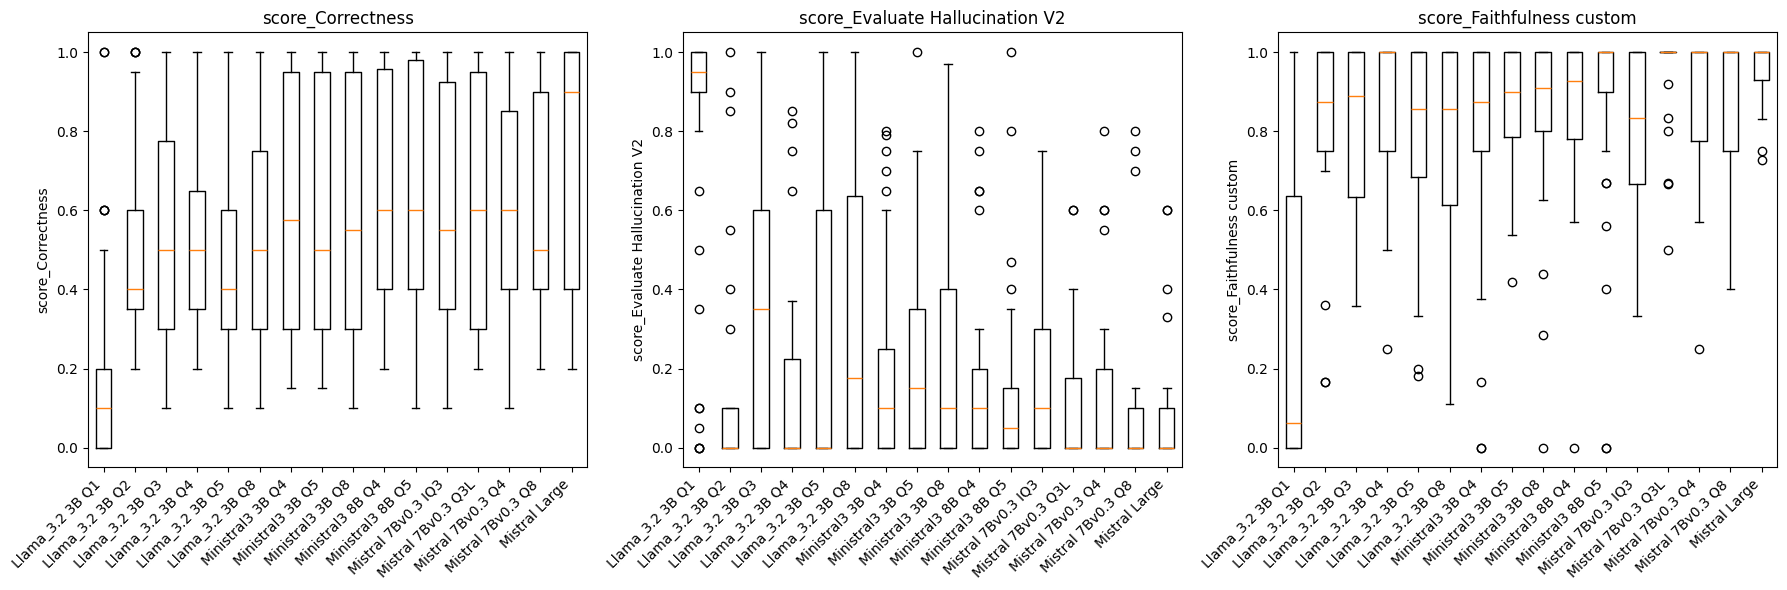

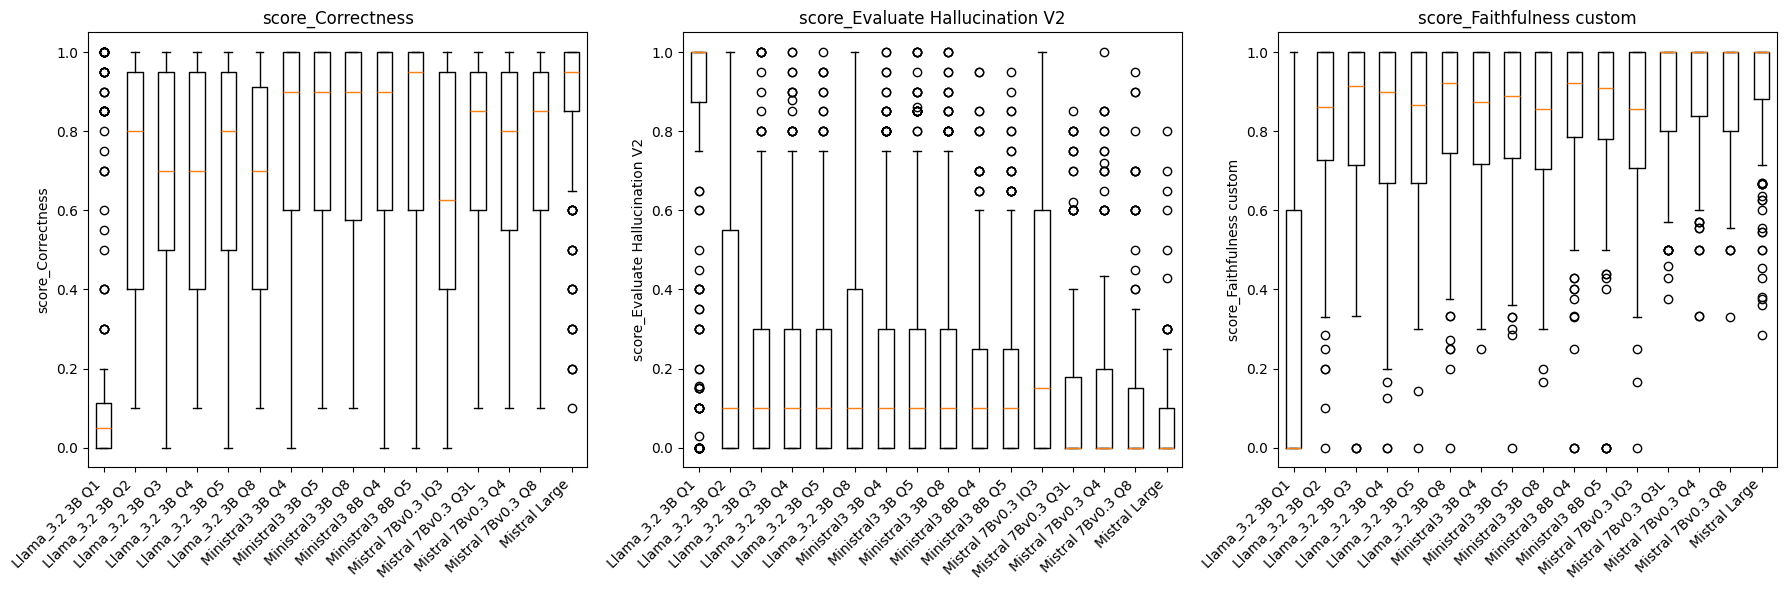

(<Figure size 1800x600 with 3 Axes>,
 [<Axes: title={'center': 'score_Correctness'}, ylabel='score_Correctness'>,
  <Axes: title={'center': 'score_Evaluate Hallucination V2'}, ylabel='score_Evaluate Hallucination V2'>,
  <Axes: title={'center': 'score_Faithfulness custom'}, ylabel='score_Faithfulness custom'>])

In [21]:
COLUMN_TO_FILTER = "metrics_recall_at_k"
CUTOFF = 0.4
df_filtered_down = df[df['metrics_recall_at_k'] < CUTOFF]

plot_stats_multi_line(df_filtered_down,
                      _present(df_filtered_down, ['score_Correctness', 'score_Evaluate Hallucination V2', "score_Faithfulness custom"]),
                      group_by="run_id", group_order=run_order, stat="mean", show_band=True, band_percentiles=(25,75), labels=labels)

df_filtered_up = df[df['metrics_recall_at_k'] > CUTOFF]
plot_stats_multi_line(df_filtered_up,
                      _present(df_filtered_up, ['score_Correctness', 'score_Evaluate Hallucination V2', "score_Faithfulness custom"]),
                      group_by="run_id", group_order=run_order, stat="mean", show_band=True, band_percentiles=(25,75), labels=labels)

plot_boxplots(df_filtered_down, ['score_Correctness', 'score_Evaluate Hallucination V2', "score_Faithfulness custom"],
              group_by="run_id", group_order=run_order, figsize=(18, 6), labels=labels)
plot_boxplots(df_filtered_up, ['score_Correctness', 'score_Evaluate Hallucination V2', "score_Faithfulness custom"],
              group_by="run_id", group_order=run_order, figsize=(18, 6), labels=labels)

## Extra: Examine behaviour of low-correctness claims across all models

In [16]:
SCORE_COL = "score_Correctness"
THRESHOLD = 0.5

# Keep only claim_ids where every run_id has score < threshold
claim_max_score = df.groupby("claim_id")[SCORE_COL].max()
claims_below_all = claim_max_score[claim_max_score < THRESHOLD].index

df_filtered_claims = df[df["claim_id"].isin(claims_below_all)]
print(f"{len(claims_below_all)} claim(s) with {SCORE_COL} < {THRESHOLD} across all run_ids")
print(f"{len(df_filtered_claims)} total rows")
print(f"Claim ID: {claims_below_all[0]}")
df_filtered_claims.groupby('run_id')['trace_id'].count()

1 claim(s) with score_Correctness < 0.5 across all run_ids
62 total rows
Claim ID: emanual_302


run_id
e5_large_llama_3_2_3B_q1_61            5
e5_large_llama_3_2_3B_q2_61            3
e5_large_llama_3_2_3B_q3_61            3
e5_large_llama_3_2_3B_q4_61            3
e5_large_llama_3_2_3B_q5_61            3
e5_large_llama_3_2_3B_q8_61            3
e5_large_mistral_large_latest_61       3
e5_large_test_ministral_3_3B_q4_61     6
e5_large_test_ministral_3_3B_q5_61     6
e5_large_test_ministral_3_3B_q8_61     5
e5_large_test_ministral_3_8B_q4_61     5
e5_large_test_ministral_3_8B_q5_61     5
e5_large_test_mistral_7B_0_3_iq3_61    3
e5_large_test_mistral_7B_0_3_q3l_61    3
e5_large_test_mistral_7B_0_3_q4_61     3
e5_large_test_mistral_7B_0_3_q8_61     3
Name: trace_id, dtype: int64

Claim ID: emanual_302
Input: How do I check scheduled viewings?
Expected response: 'To check scheduled viewings, you can follow these steps:

1. Open the Smart Hub by pressing the button on your remote.
2. Use the left or right directional button to move to Live TV.
3. Press the up directional button to move to the top row.
4. Use the left or right directional button to move to Schedule Manager Recordings.
5. Press Select to open Schedule Manager Recordings.
6. Use the up directional button to move to the Schedules menu.
7. Use the down directional button to move to the list of programs scheduled to view.

From there, you can see the list of programs that are scheduled for viewing.'

Context: Cancelling a scheduled viewing. 
You have two ways to cancel a scheduled viewing:

1. Cancelling a scheduled viewing from the Guide / Live TV Guide
   - Move to the program you want to cancel scheduled viewing for, and then press the Select button. 
   - Move to 'Cancel Scheduled Viewing', and the

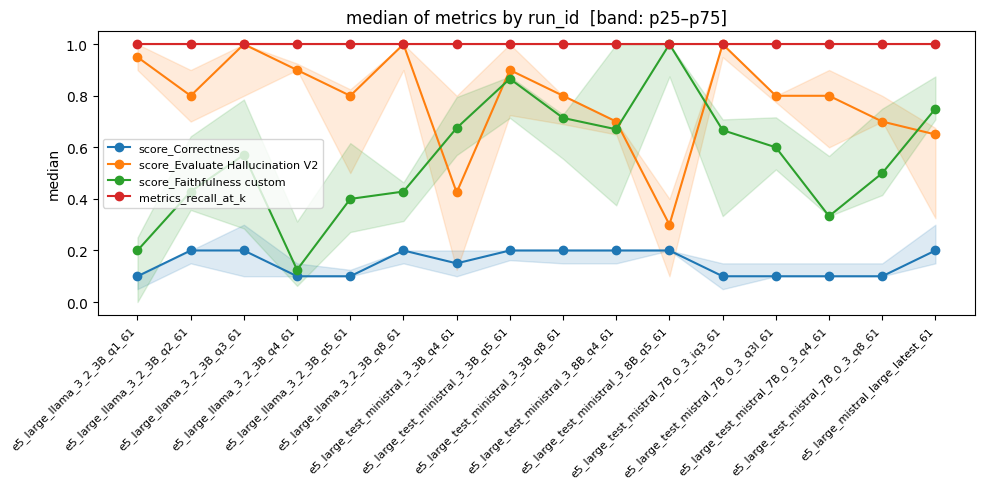

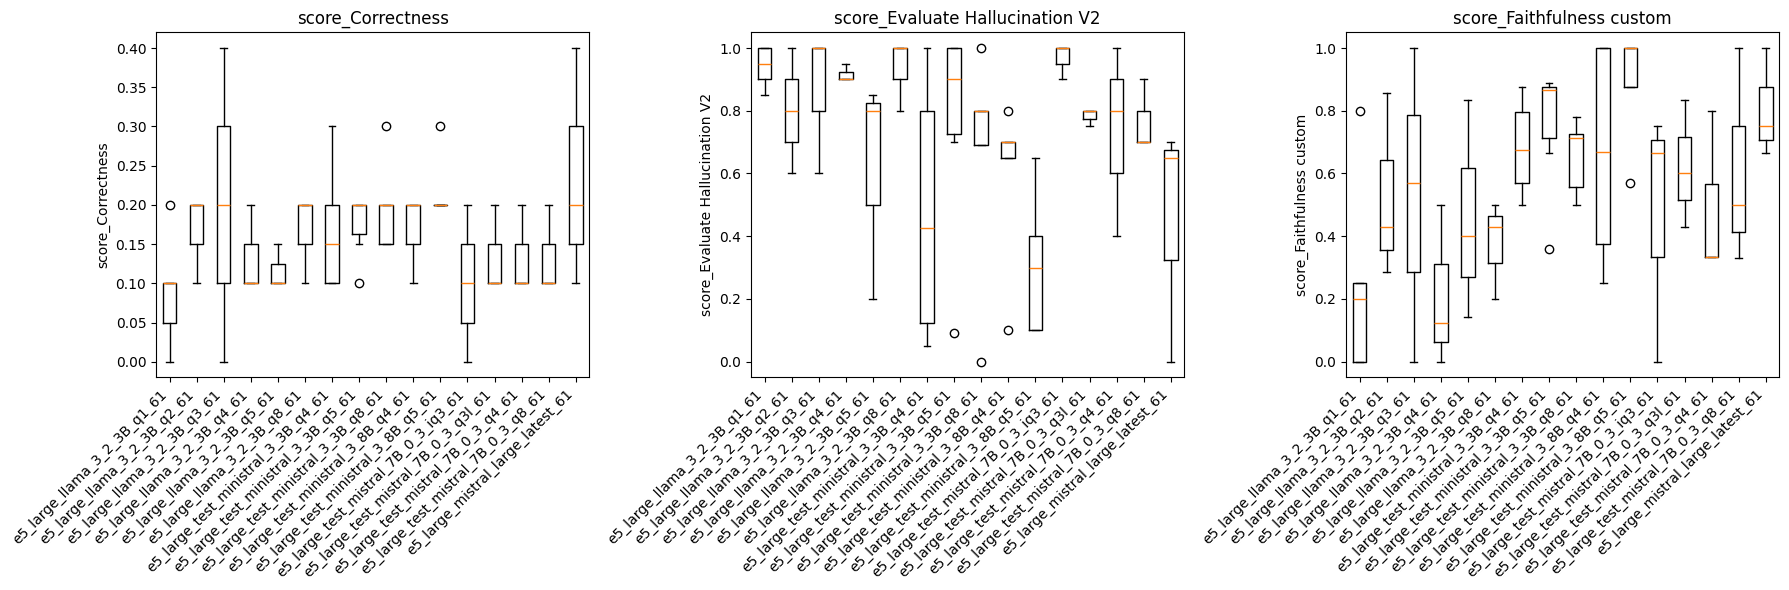

(<Figure size 1800x600 with 3 Axes>,
 [<Axes: title={'center': 'score_Correctness'}, ylabel='score_Correctness'>,
  <Axes: title={'center': 'score_Evaluate Hallucination V2'}, ylabel='score_Evaluate Hallucination V2'>,
  <Axes: title={'center': 'score_Faithfulness custom'}, ylabel='score_Faithfulness custom'>])

In [17]:
print(f"Claim ID: {claims_below_all[0]}")
print("Input: How do I check scheduled viewings?")
print("Expected response: 'To check scheduled viewings, you can follow these steps:\n\n1. Open the Smart Hub by pressing the button on your remote.\n2. Use the left or right directional button to move to Live TV.\n3. Press the up directional button to move to the top row.\n4. Use the left or right directional button to move to Schedule Manager Recordings.\n5. Press Select to open Schedule Manager Recordings.\n6. Use the up directional button to move to the Schedules menu.\n7. Use the down directional button to move to the list of programs scheduled to view.\n\nFrom there, you can see the list of programs that are scheduled for viewing.'")
print("""
Context: Cancelling a scheduled viewing. 
You have two ways to cancel a scheduled viewing:

1. Cancelling a scheduled viewing from the Guide / Live TV Guide
   - Move to the program you want to cancel scheduled viewing for, and then press the Select button. 
   - Move to 'Cancel Scheduled Viewing', and then press the Select button. 
   - When a pop-up message asking you to cancel the selected scheduled viewing appears, select 'Yes'. 
   - The selected scheduled viewing is canceled and the screen returns to the Guide screen.

2. Setting up a scheduled viewing for a channel
   - Using the schedule viewing options from the guide screen: On the Guide screen, select a program you would like to view, press and hold the Select button, and then select 'Schedule Viewing' in the pop-up menu that appears.
   - Using the schedule viewing options in the program info window: Press the Select button while watching TV. The Program Info window appears. Select a program that will be broadcast using the left or right directional buttons. Press and hold the Select button. Select 'Schedule Viewing' on the pop-up menu that appears.

The Program Info Screen:
Press the Select button while watching the TV. The Program Info window appears. Select a broadcast scheduled program by using the left or right directional buttons, and then press the Select button. You can schedule watching the program by selecting 'Schedule Viewing'.

Setting Up a Schedule Viewing:
Configure the TV to show a specific channel or program at a specific time and date. The icon appears next to programs that have been configured for a schedule viewing. 

Note: To set up a schedule viewing, you must first set the TV's clock (Settings > General > System Manager > Time > Clock).

Scheduling viewing from the program info window:
Press the Select button while viewing a program to display the program info window. In the program info window, use the left and right directional buttons to select a broadcast scheduled program, and then press the Select button. To schedule a recording for the program, select 'Schedule Recording'.
""")
plot_stats_multi_line(df_filtered_claims,
                      _present(df_filtered_claims, ['score_Correctness', 'score_Evaluate Hallucination V2', "score_Faithfulness custom", "metrics_recall_at_k"]),
                      group_by="run_id", group_order=run_order, stat="median", show_band=True)

plot_boxplots(df_filtered_claims, ['score_Correctness', 'score_Evaluate Hallucination V2', "score_Faithfulness custom"],
              group_by="run_id", group_order=run_order, figsize=(18, 6))

## Extra: examine high-hallucination claims accross run IDs

In [18]:
SCORE_COL = "score_Evaluate Hallucination V2"
THRESHOLD = 0.6

# Keep only claim_ids where every run_id has score < threshold
claim_max_score = df.groupby("claim_id")[SCORE_COL].max()
claims_below_all = claim_max_score[claim_max_score > THRESHOLD]
claims_below_all = claims_below_all.index
df_filtered_claims = df[df["claim_id"].isin(claims_below_all)]
print(f"{len(claims_below_all)} claim(s) with {SCORE_COL} > {THRESHOLD} across all run_ids")
print(f"{len(df_filtered_claims)} total rows")
print(f"Claim ID: {claims_below_all}")
df_filtered_claims.groupby('run_id')['trace_id'].count()

61 claim(s) with score_Evaluate Hallucination V2 > 0.6 across all run_ids
3782 total rows
Claim ID: Index(['emanual_1', 'emanual_114', 'emanual_116', 'emanual_132', 'emanual_14',
       'emanual_145', 'emanual_176', 'emanual_188', 'emanual_19',
       'emanual_191', 'emanual_229', 'emanual_237', 'emanual_257',
       'emanual_282', 'emanual_283', 'emanual_284', 'emanual_289',
       'emanual_300', 'emanual_302', 'emanual_305', 'emanual_310',
       'emanual_32', 'emanual_333', 'emanual_341', 'emanual_353',
       'emanual_359', 'emanual_363', 'emanual_365', 'emanual_371',
       'emanual_395', 'emanual_4', 'emanual_413', 'emanual_420', 'emanual_426',
       'emanual_430', 'emanual_433', 'emanual_442', 'emanual_451',
       'emanual_454', 'emanual_465', 'emanual_466', 'emanual_467',
       'emanual_473', 'emanual_486', 'emanual_490', 'emanual_535',
       'emanual_539', 'emanual_543', 'emanual_548', 'emanual_558',
       'emanual_568', 'emanual_577', 'emanual_59', 'emanual_594',
       

run_id
e5_large_llama_3_2_3B_q1_61            305
e5_large_llama_3_2_3B_q2_61            183
e5_large_llama_3_2_3B_q3_61            183
e5_large_llama_3_2_3B_q4_61            183
e5_large_llama_3_2_3B_q5_61            183
e5_large_llama_3_2_3B_q8_61            183
e5_large_mistral_large_latest_61       183
e5_large_test_ministral_3_3B_q4_61     366
e5_large_test_ministral_3_3B_q5_61     366
e5_large_test_ministral_3_3B_q8_61     305
e5_large_test_ministral_3_8B_q4_61     305
e5_large_test_ministral_3_8B_q5_61     305
e5_large_test_mistral_7B_0_3_iq3_61    183
e5_large_test_mistral_7B_0_3_q3l_61    183
e5_large_test_mistral_7B_0_3_q4_61     183
e5_large_test_mistral_7B_0_3_q8_61     183
Name: trace_id, dtype: int64

## 2.3  Histogram Grids by Run ID

In [19]:
# plot_latency_as_hist(df, group_by="run_id", group_order=run_order)
# plot_generation_as_hist(df, group_by="run_id", group_order=run_order)
# plot_retrieval_as_hist(df, group_by="run_id", group_order=run_order)
# plot_hardware_as_hist(df, group_by="run_id", group_order=run_order)
# plot_generation_quality_as_hist(df, group_by="run_id", group_order=run_order)

## 2.4  Scatter: Two Metrics by Run ID

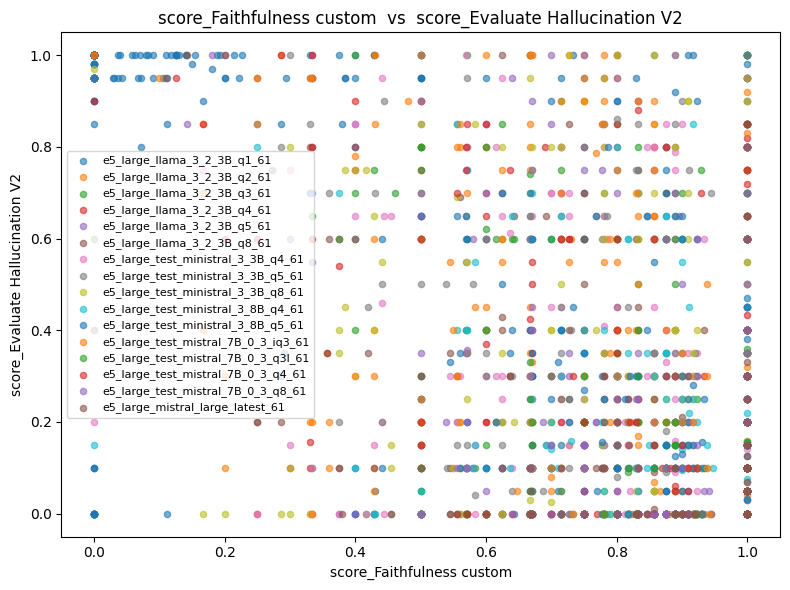

(<Figure size 800x600 with 1 Axes>,
 <Axes: title={'center': 'score_Faithfulness custom  vs  score_Evaluate Hallucination V2'}, xlabel='score_Faithfulness custom', ylabel='score_Evaluate Hallucination V2'>)

In [20]:
plot_scatter_two_metrics(
    df, "score_Faithfulness custom", "score_Evaluate Hallucination V2",
    group_by="run_id", group_order=run_order,
)

## 2.5  Heatmap: metric by run_id × claim_id

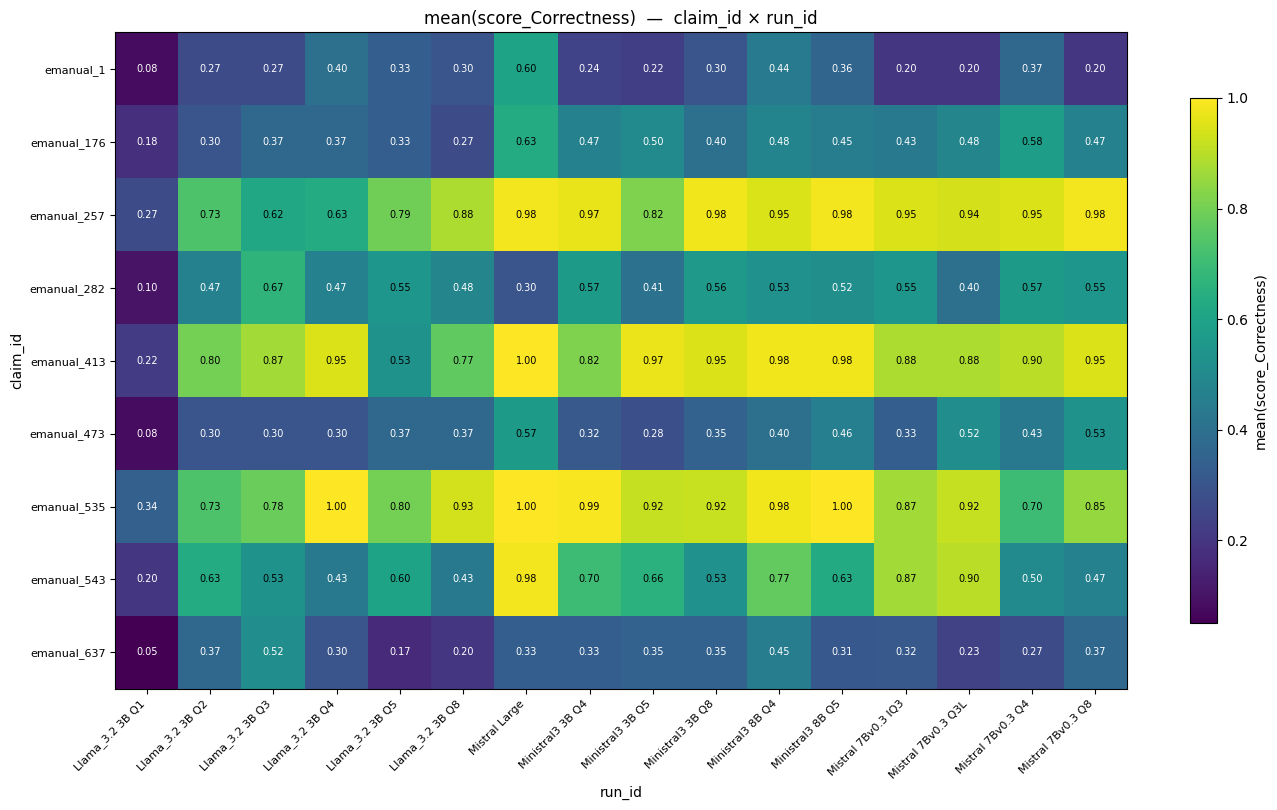

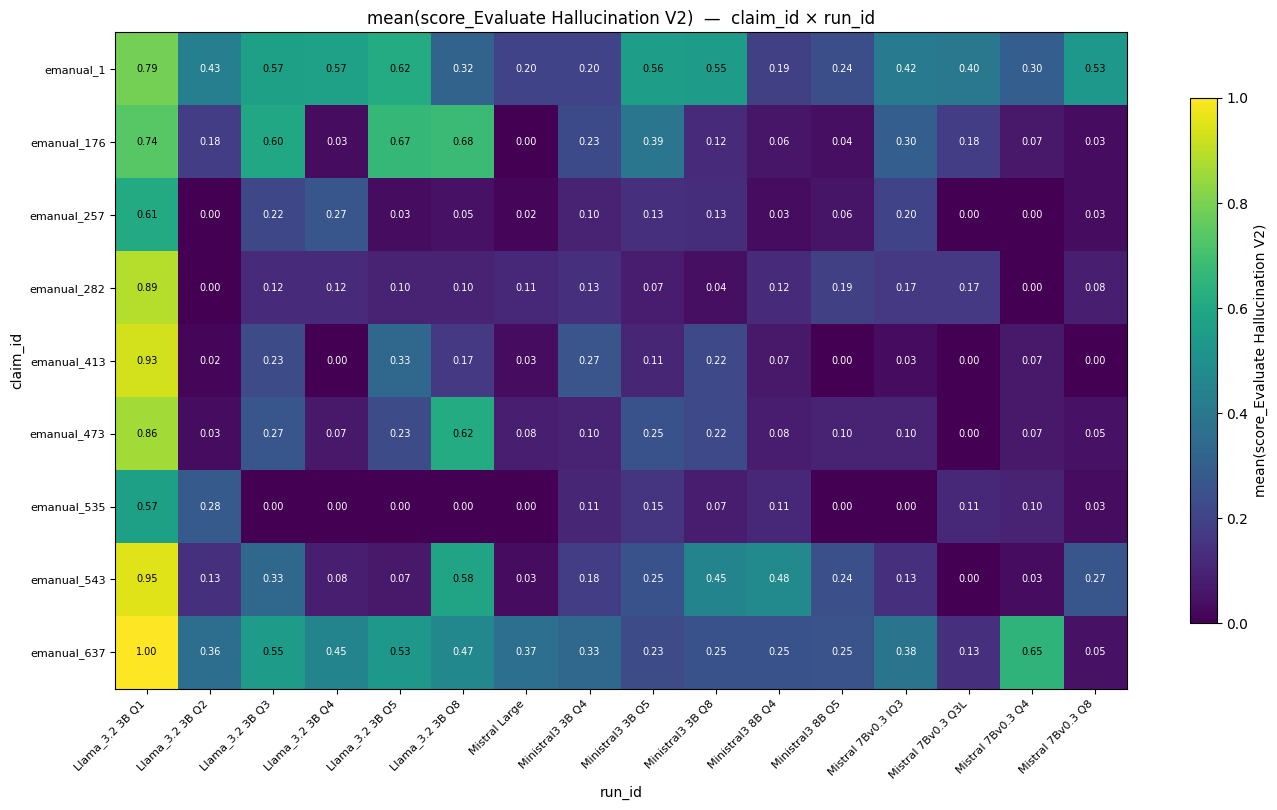

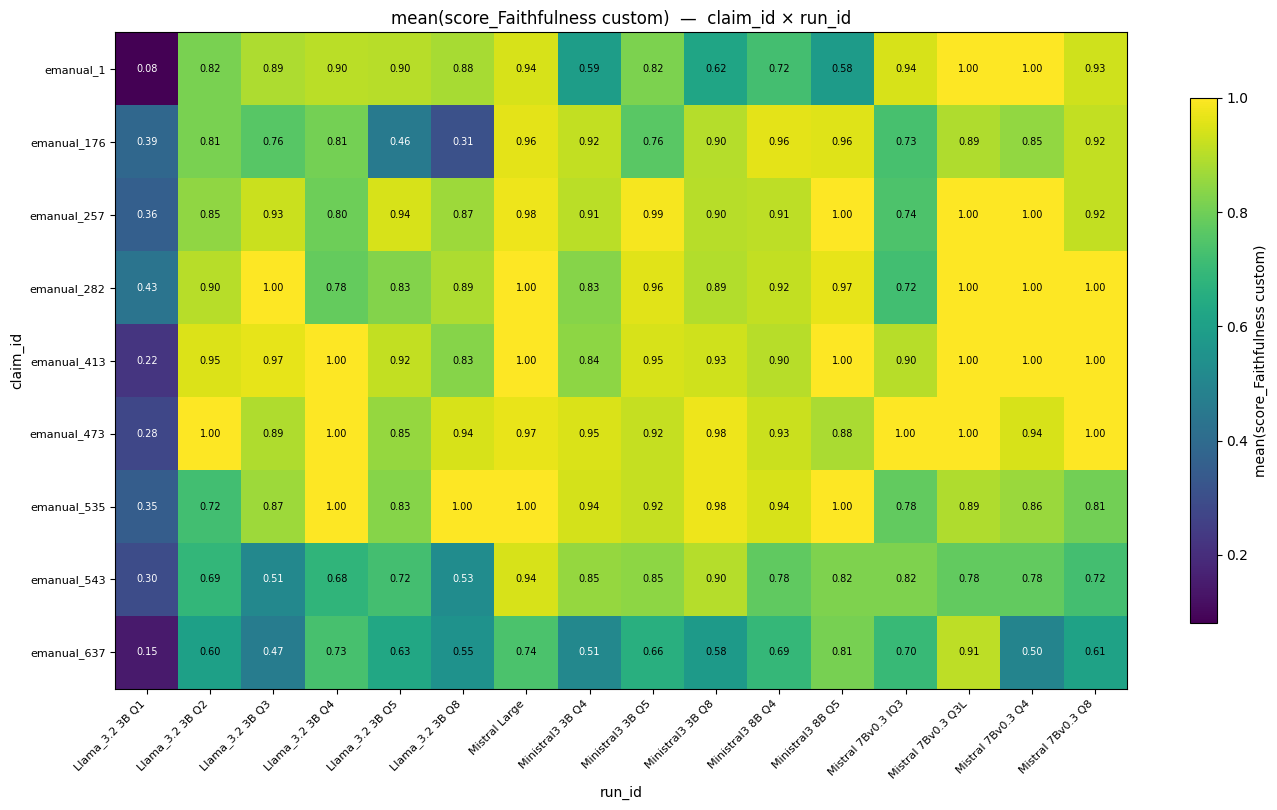

(<Figure size 1400x820 with 2 Axes>,
 <Axes: title={'center': 'mean(score_Faithfulness custom)  —  claim_id × run_id'}, xlabel='run_id', ylabel='claim_id'>)

In [20]:
# Default: mean of score_Correctness per (run_id, claim_id)
down_selection = ["e5_large_test_ministral_3_3B_q4_61",
        "e5_large_test_ministral_3_3B_q5_61",
        "e5_large_test_ministral_3_3B_q8_61",
        "e5_large_test_mistral_7B_0_3_q4_61", 
        # "e5_large_test_mistral_7B_0_3_q8_61", 
        "e5_large_mistral_large_latest_61",
        ]
df_small = df[df["run_id"].isin(down_selection)]
plot_heatmap(df_filtered_down, metric="score_Correctness", labels=labels)
plot_heatmap(df_filtered_down, metric="score_Evaluate Hallucination V2", labels=labels)
# plot_heatmap(df_small, metric="score_Evaluate Hallucination V2", agg="std", labels=labels, var1_order=down_selection)
plot_heatmap(df_filtered_down, metric="score_Faithfulness custom", labels=labels)
# plot_heatmap(df_small, metric="score_Faithfulness custom", agg="std", labels=labels, var1_order=down_selection)
# plot_heatmap(df_small, metric="metrics_recall_at_k", labels=labels, var1_order=down_selection)

# plot_heatmap(df, metric="score_Correctness", labels=labels)
# plot_heatmap(df, metric="score_Evaluate Hallucination V2", labels=labels)
# plot_heatmap(df, metric="score_Evaluate Hallucination V2", agg="std", labels=labels)
# plot_heatmap(df, metric="score_Faithfulness custom", labels=labels)
# plot_heatmap(df, metric="score_Faithfulness custom", agg="std", labels=labels)
# plot_heatmap(df, metric="metrics_recall_at_k", labels=labels)

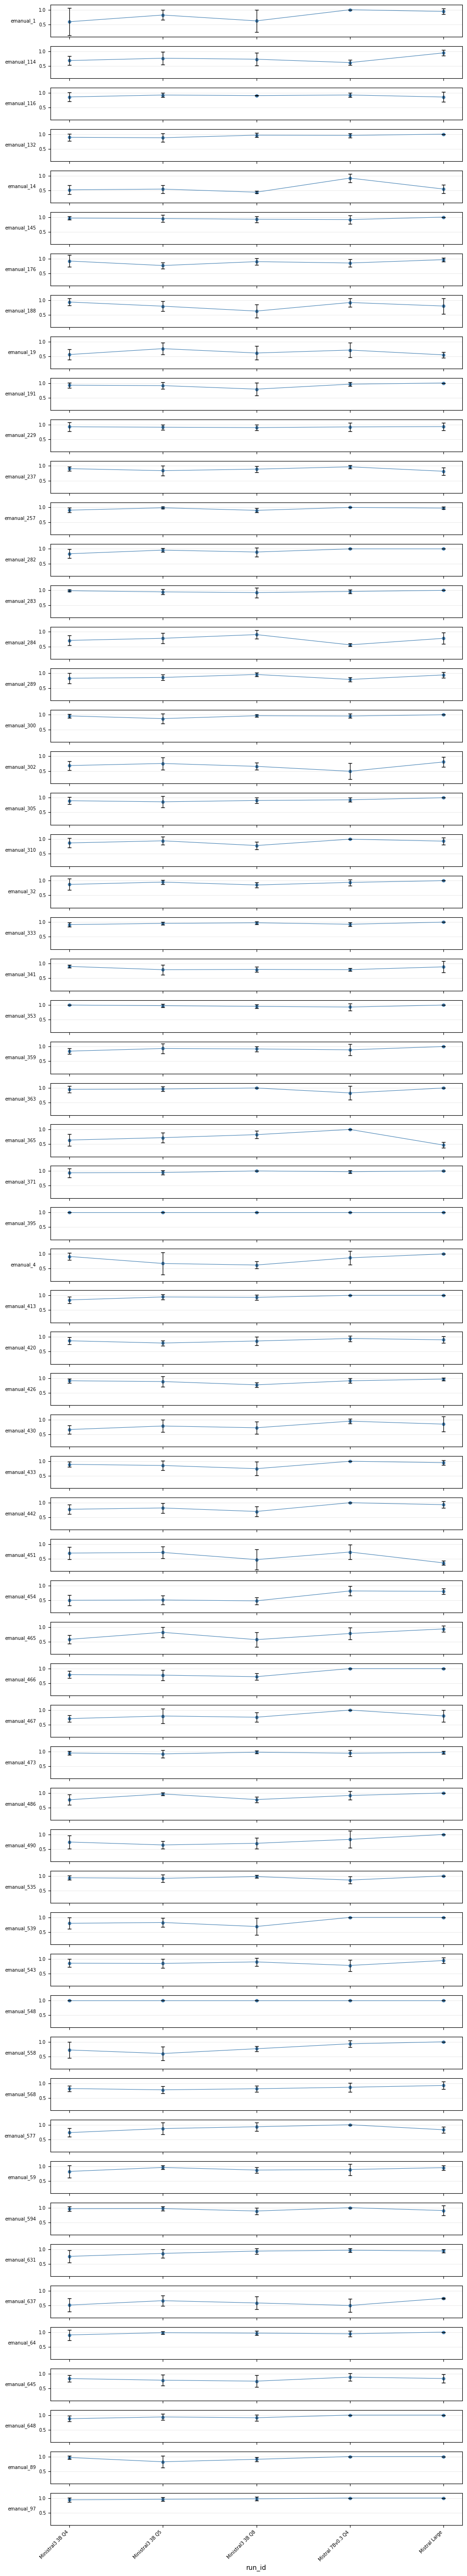

(<Figure size 1000x5490 with 61 Axes>,
 [<Axes: ylabel='emanual_1'>,
  <Axes: ylabel='emanual_114'>,
  <Axes: ylabel='emanual_116'>,
  <Axes: ylabel='emanual_132'>,
  <Axes: ylabel='emanual_14'>,
  <Axes: ylabel='emanual_145'>,
  <Axes: ylabel='emanual_176'>,
  <Axes: ylabel='emanual_188'>,
  <Axes: ylabel='emanual_19'>,
  <Axes: ylabel='emanual_191'>,
  <Axes: ylabel='emanual_229'>,
  <Axes: ylabel='emanual_237'>,
  <Axes: ylabel='emanual_257'>,
  <Axes: ylabel='emanual_282'>,
  <Axes: ylabel='emanual_283'>,
  <Axes: ylabel='emanual_284'>,
  <Axes: ylabel='emanual_289'>,
  <Axes: ylabel='emanual_300'>,
  <Axes: ylabel='emanual_302'>,
  <Axes: ylabel='emanual_305'>,
  <Axes: ylabel='emanual_310'>,
  <Axes: ylabel='emanual_32'>,
  <Axes: ylabel='emanual_333'>,
  <Axes: ylabel='emanual_341'>,
  <Axes: ylabel='emanual_353'>,
  <Axes: ylabel='emanual_359'>,
  <Axes: ylabel='emanual_363'>,
  <Axes: ylabel='emanual_365'>,
  <Axes: ylabel='emanual_371'>,
  <Axes: ylabel='emanual_395'>,
  <Axe

In [33]:
plot_dot_profiles(
    df_small,
    metric="score_Faithfulness custom",
    var1_order=down_selection,
    show_std=True,
    sharey=True,
    labels=labels,
    figsize_per_row=(10, 0.9),
    title=""
)

emanual_284


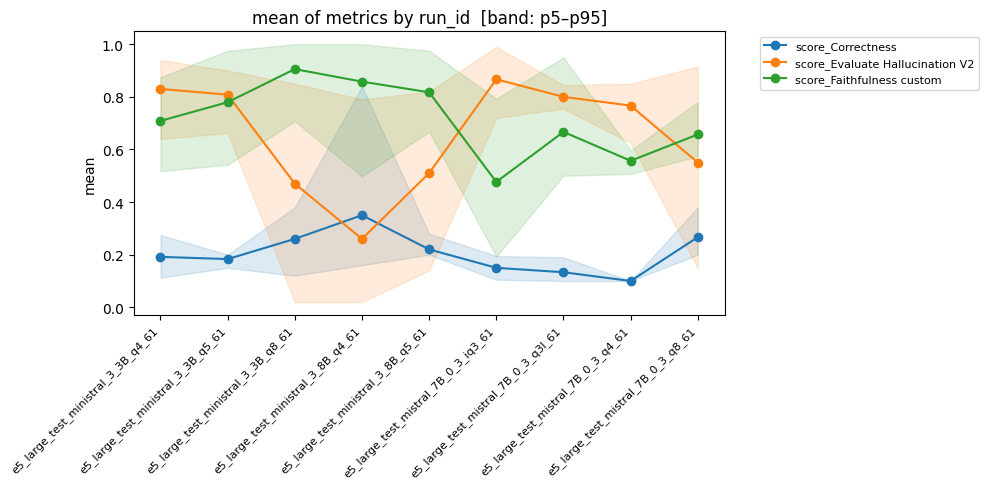

emanual_302


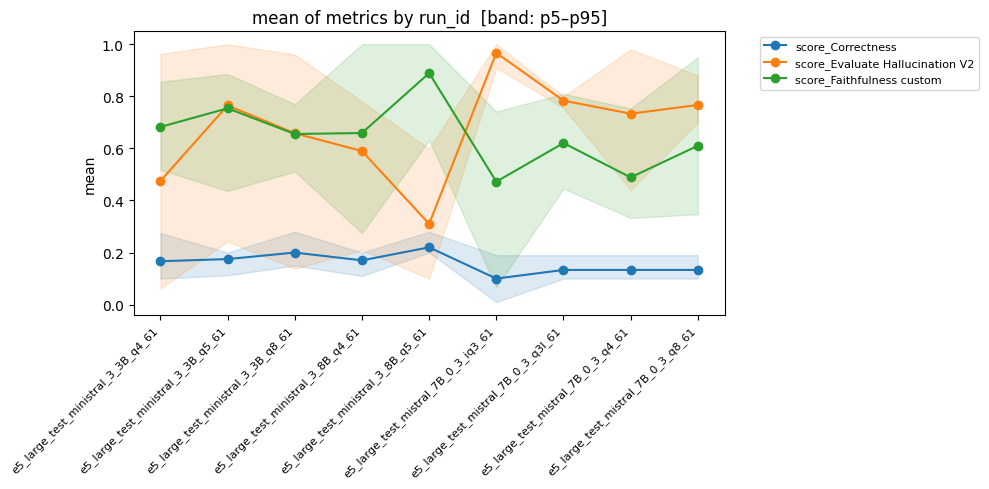

emanual_454


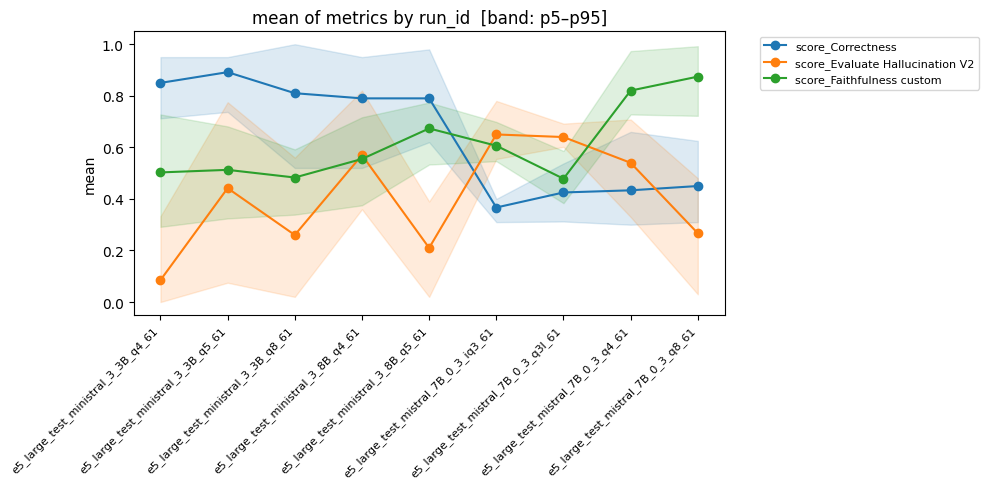

In [65]:
claims_to_show = ["emanual_284", "emanual_302", "emanual_454"]

for claim in claims_to_show:
    df_filtered_claim = df[df["claim_id"] == claim]
    print(claim)
    plot_stats_multi_line(df_filtered_claim, _present(df, ["score_Correctness",
                                    "score_Evaluate Hallucination V2", "score_Faithfulness custom"]),
                        group_by="run_id", group_order=run_order, stat="mean", show_band=True, band_percentiles=(5,95))

---
# 3  Stability Analysis — Repeated Sessions of One Run ID

Multiple sessions (files) that share the same `run_id` let us assess run-to-run stability.
The `session_id` is the x-axis; one subplot per metric.

In [101]:
# Select the run_id to analyse for stability
STABILITY_RUN_ID = get_run_ids(df)[0]  # replace with a string literal
# STABILITY_RUN_ID = "e5_large_test_mistral_7B_0_3_q8_61"
STABILITY_RUN_ID = "e5_large_llama_3_2_3B_q1_61"

df_stable = df[df["run_id"] == STABILITY_RUN_ID].copy()
stable_sessions = get_session_ids(df_stable)

print(f"Run ID:   {STABILITY_RUN_ID}")
print(f"Sessions ({len(stable_sessions)}):")
for s in stable_sessions:
    print(f"  {s}")

Run ID:   e5_large_llama_3_2_3B_q1_61
Sessions (5):
  e5_large_llama_3_2_3B_q1_61_0ec85db0
  e5_large_llama_3_2_3B_q1_61_97751e2d
  e5_large_llama_3_2_3B_q1_61_af7a8aff
  e5_large_llama_3_2_3B_q1_61_f8e4ed21
  e5_large_llama_3_2_3B_q1_61_fd094413


In [53]:
stats_by_group(df_stable, group_by="session_id")

latency_ms                              \
                                          count      mean       std     min   
session_id                                                                    
e5_large_llama_3_2_3B_q8_61_3ae02197       61.0  4991.443  1939.018  2027.0   
e5_large_llama_3_2_3B_q8_61_4b9b1e6f       61.0  5593.033  1534.219  2076.0   
e5_large_llama_3_2_3B_q8_61_b3c86b91       61.0  5364.311  1835.123  1609.0   

                                                                      \
                                         25%     50%     75%     max   
session_id                                                             
e5_large_llama_3_2_3B_q8_61_3ae02197  3411.0  4749.0  6979.0  8633.0   
e5_large_llama_3_2_3B_q8_61_4b9b1e6f  4787.0  6156.0  6740.0  8822.0   
e5_large_llama_3_2_3B_q8_61_b3c86b91  3971.0  5525.0  7062.0  8526.0   

                                     latency_ttft_ms           ...  \
                                               count     mean  ...   
session_id                                                     ...   
e5_large_llama_3_2_3B_q8_61_3ae02197            61.0  894.402  ...   
e5_large_llama_3_2_3B_q8_61_4b9b1e6f            61.0  929.233  ...   
e5_large_llama_3_2_3B_q8_61_b3c86b91            61.0  868.147  ...   

                                     score_Evaluate Hallucination V2       \
                                                                 75%  max   
session_id                                                                  
e5_large_llama_3_2_3B_q8_61_3ae02197                            0.45  1.0   
e5_large_llama_3_2_3B_q8_61_4b9b1e6f                            0.20  1.0   
e5_large_llama_3_2_3B_q8_61_b3c86b91                            0.66  1.0   

                                     score_Correctness                     \
                                                 count   mean    std  min   
session_id                                                                  
e5_large_llama_3_2_3B_q8_61_3ae02197              61.0  0.590  0.260  0.1   
e5_large_llama_3_2_3B_q8_61_4b9b1e6f              61.0  0.759  0.281  0.1   
e5_large_llama_3_2_3B_q8_61_b3c86b91              61.0  0.584  0.273  0.1   

                                                           
                                      25%   50%  75%  max  
session_id                                                 
e5_large_llama_3_2_3B_q8_61_3ae02197  0.4  0.55  0.8  1.0  
e5_large_llama_3_2_3B_q8_61_4b9b1e6f  0.6  0.90  1.0  1.0  
e5_large_llama_3_2_3B_q8_61_b3c86b91  0.4  0.60  0.8  1.0  

[3 rows x 168 columns]

## Timeline analysis

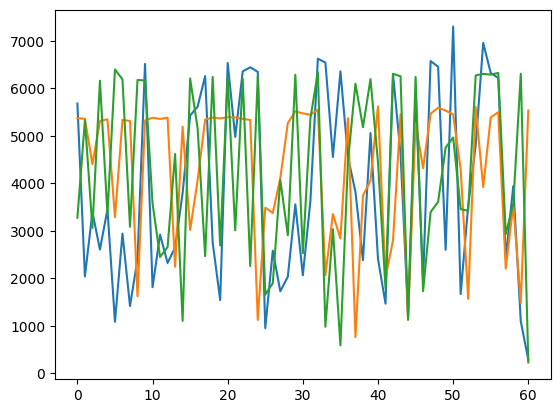

In [54]:
import matplotlib.pyplot as plot

plt.figure()
for s in stable_sessions:
    test1 = df_stable[df_stable["session_id"] == s]
    x = list(range(len(test1)))
    plt.plot(x, test1["latency_llm_generation_latency_ms"])

## 3.1  Boxplots — Session ID as x-axis

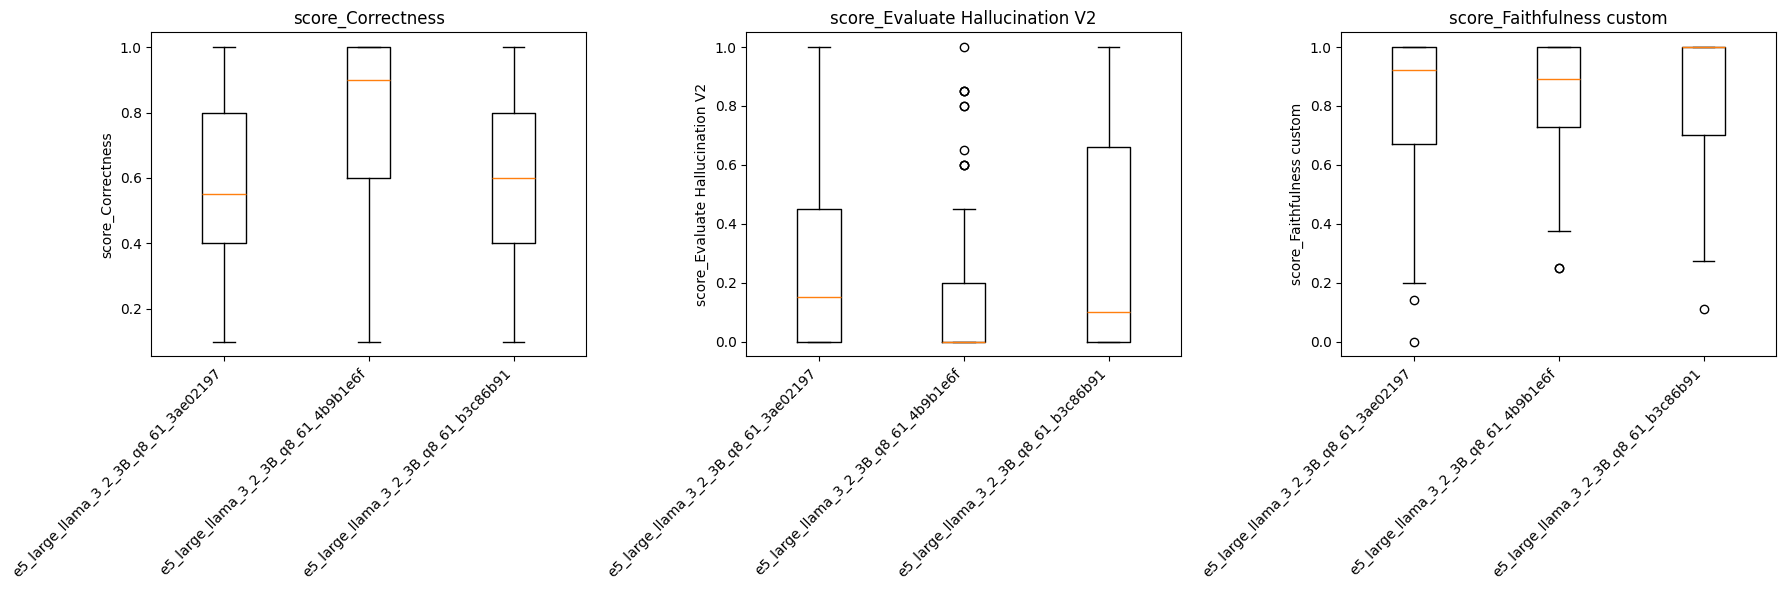

(<Figure size 1800x600 with 3 Axes>,
 [<Axes: title={'center': 'score_Correctness'}, ylabel='score_Correctness'>,
  <Axes: title={'center': 'score_Evaluate Hallucination V2'}, ylabel='score_Evaluate Hallucination V2'>,
  <Axes: title={'center': 'score_Faithfulness custom'}, ylabel='score_Faithfulness custom'>])

In [55]:
plot_boxplots(df_stable, ["score_Correctness", "score_Evaluate Hallucination V2", "score_Faithfulness custom"],
              group_by="session_id", group_order=stable_sessions, figsize=(18, 6))

## 3.2  Histogram Grids — Sessions as rows

In [56]:
# plot_generation_quality_as_hist(df_stable, group_by="session_id", group_order=stable_sessions)
# plot_latency_as_hist(df_stable, group_by="session_id", group_order=stable_sessions)
# plot_generation_as_hist(df_stable, group_by="session_id", group_order=stable_sessions)
# plot_hardware_as_hist(df_stable, group_by="session_id", group_order=stable_sessions)
# plot_retrieval_as_hist(df_stable, group_by="session_id", group_order=stable_sessions)

## 3.3  Stats Across Sessions

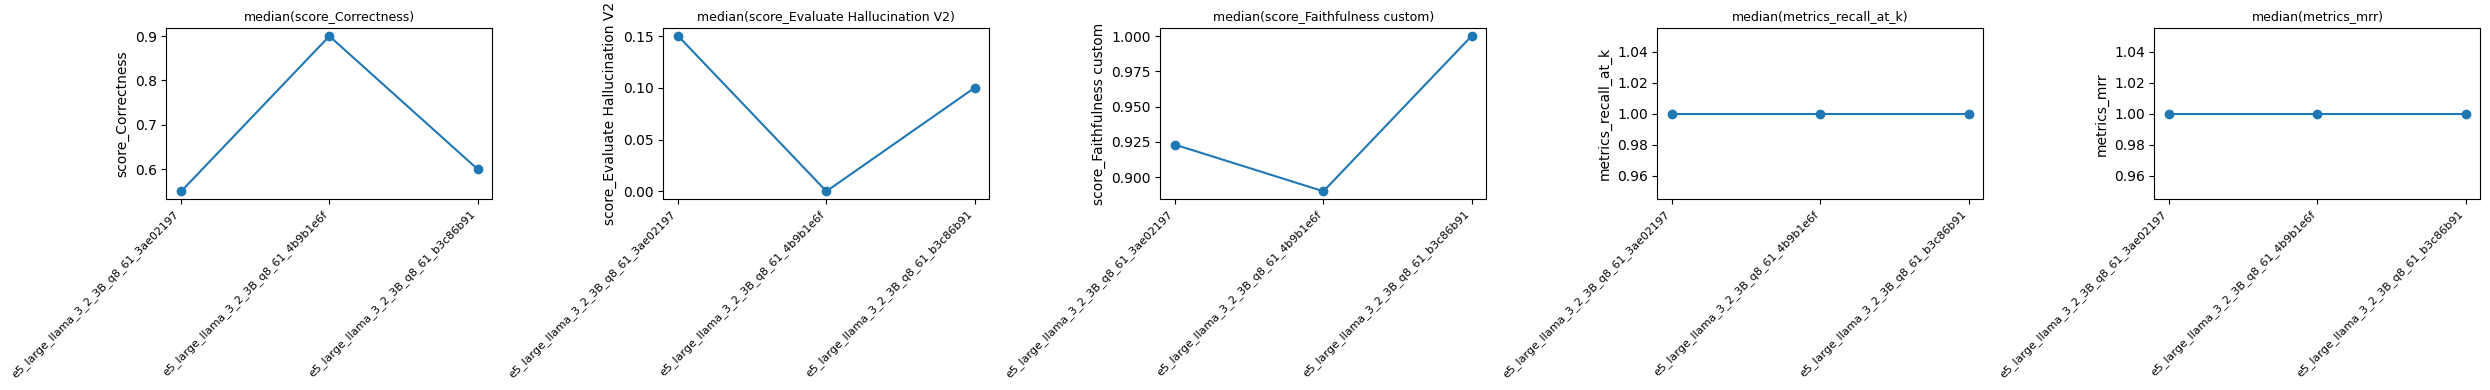

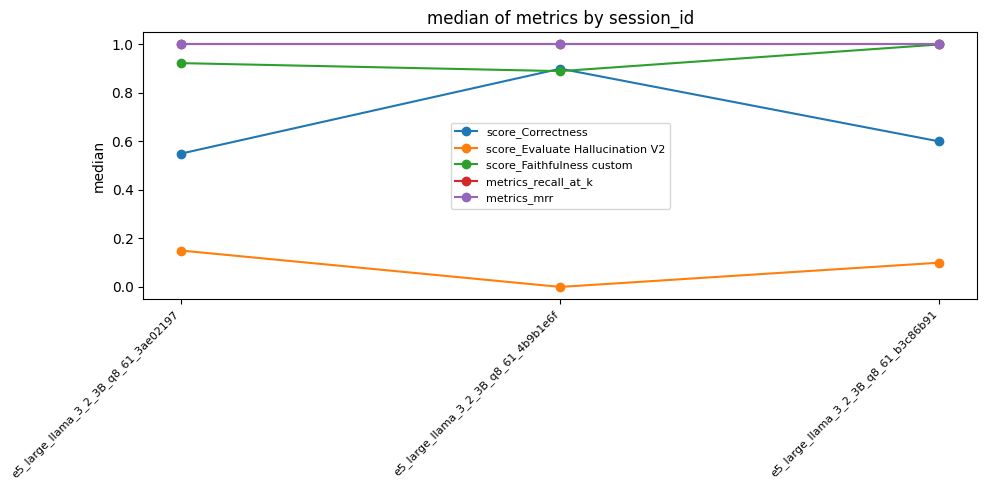

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'median of metrics by session_id'}, ylabel='median'>)

In [57]:
# Mean of each metric across sessions — one subplot per metric
plot_stats_line(df_stable, _present(df_stable, GENERATION_QUALITY_COLS),
                group_by="session_id", group_order=stable_sessions, stat="median")
# All quality metrics overlaid in one plot (normalized so different scales are comparable)
plot_stats_multi_line(
    df_stable,
    _present(df_stable, GENERATION_QUALITY_COLS),
    group_by="session_id", group_order=stable_sessions,
    stat="median", normalize=False
)

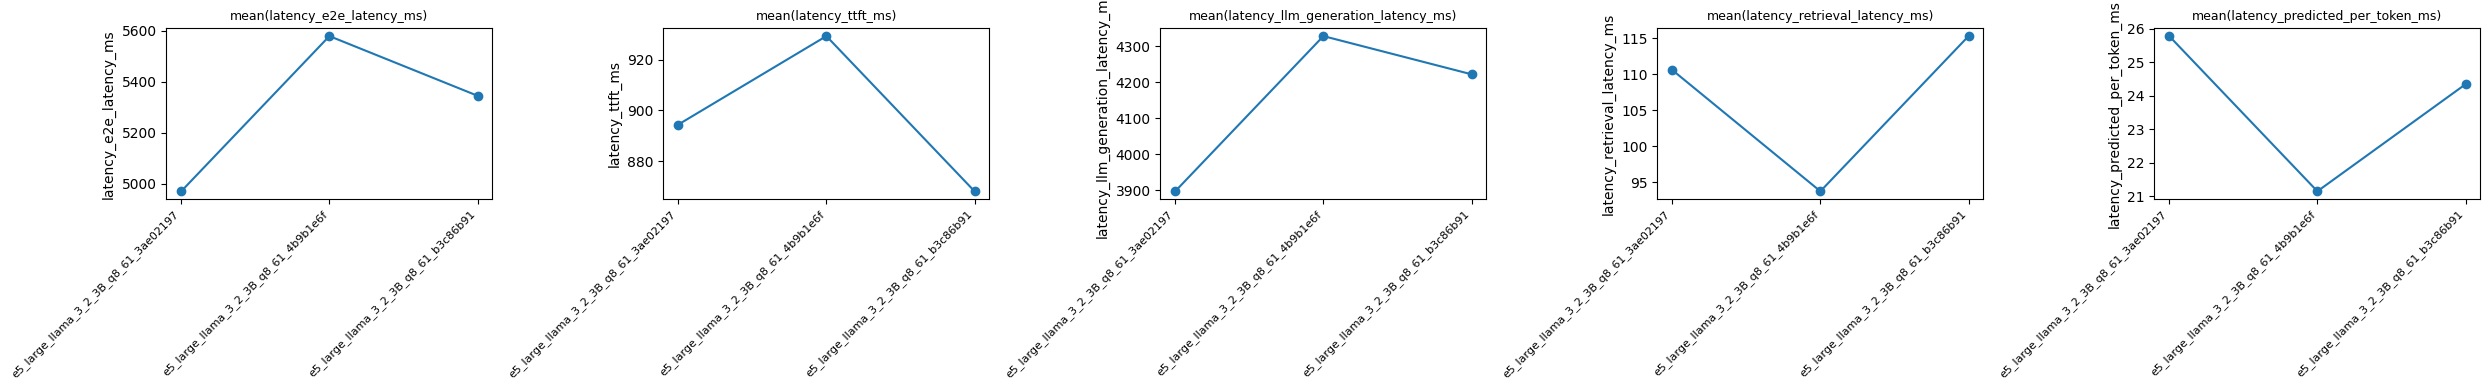

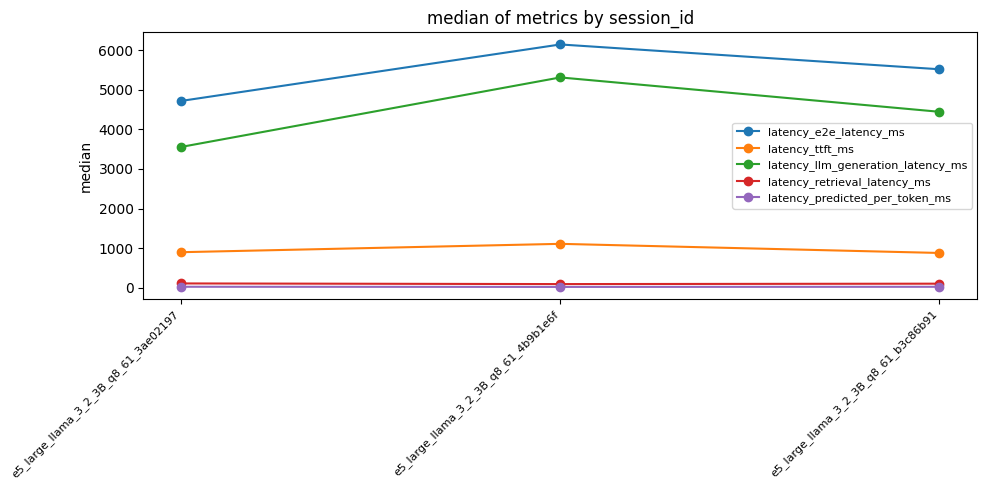

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'median of metrics by session_id'}, ylabel='median'>)

In [58]:
# Latency stability across sessions
plot_stats_line(df_stable, _present(df_stable, LATENCY_COLS),
                group_by="session_id", group_order=stable_sessions, stat="mean")
plot_stats_multi_line(df_stable, _present(df_stable, LATENCY_COLS),
                      group_by="session_id", group_order=stable_sessions,
                      stat="median", normalize=False)

In [ ]:
plot_stats_bar(df_stable, _present(df_stable, [*RETRIEVAL_COLS, "score_Correctness", "score_Evaluate Hallucination V2"]),
               group_by="session_id", group_order=stable_sessions, stat="mean", show_std=True)

plot_stats_bar(df_stable, _present(df_stable, LATENCY_COLS),
               group_by="session_id", group_order=stable_sessions, stat="mean", show_std=True)

plot_stats_bar(df_stable, _present(df_stable, HARDWARE_COLS),
               group_by="session_id", group_order=stable_sessions, stat="mean", show_std=True)